# Proyecto Final – Text Mining & Image Recognition
**Postgrado en Análisis y Predicción de Datos – Universidad Galileo**
**Tercer Trimestre, 2026**

---

# Problema 1: Word Cloud

## Introducción

En este problema trabajamos con un dataset de **1.6 millones de tweets** (Sentiment140), publicados entre abril y junio de 2009. El objetivo es:

1. Identificar, mediante **expresiones regulares**, los **3 usuarios más populares** del dataset.
2. Construir un **corpus por usuario** que contenga el tweet (contenido) y sus metadatos: **ID, Timestamp y Length**.
3. Extraer el **contexto** que rodea a cada mención para responder: **¿por qué citan a ese usuario?**

Para limpiar el texto aplicaremos remoción de stopwords, stemming y lematización. Finalmente, visualizaremos las **10 palabras más frecuentes** de cada usuario en un wordcloud.

### ¿Qué entendemos por "usuario popular"?

En Twitter, un usuario es popular cuando **otros hablan de él**, no cuando él publica mucho. Por eso definimos popularidad como el **número de veces que un usuario es mencionado** (`@usuario`) en los tweets de otras personas. 

In [8]:
# Librerías para manipulación de datos y expresiones regulares
import re
import pandas as pd
import matplotlib.pyplot as plt

import os

# Crear la carpeta de salidas si no existe
os.makedirs('outputs', exist_ok=True)

# Opciones de visualización de pandas: mostrar el texto completo de los tweets
pd.set_option('display.max_colwidth', 150)

## 1.1 Carga del dataset

El archivo `tw_source.csv` **no tiene encabezados**, por lo que asignamos los nombres de columna manualmente según la documentación de Sentiment140:

| Columna | Descripción |
|---|---|
| `target` | Sentimiento del tweet (0 = negativo, 4 = positivo) |
| `id` | Identificador único del tweet |
| `date` | Fecha y hora de publicación |
| `flag` | Query de búsqueda (en este dataset siempre es `NO_QUERY`) |
| `user` | Usuario que publicó el tweet |
| `text` | Contenido del tweet |

El archivo usa codificación **latin-1**. Si se intenta leer como UTF-8 (el valor por defecto), pandas lanza un `UnicodeDecodeError`, porque algunos tweets contienen caracteres especiales.

In [4]:
# Nombres de las columnas (el archivo no trae encabezados)
columnas = ['target', 'id', 'date', 'flag', 'user', 'text']

# Carga del dataset con codificación latin-1
df = pd.read_csv('tw_source.csv/tw_source.csv', header=None, names=columnas, encoding='latin-1')

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 1,600,000 filas x 6 columnas


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


In [5]:
# Tipos de datos y valores nulos
print("=== Tipos de datos ===")
print(df.dtypes, "\n")

print("=== Valores nulos por columna ===")
print(df.isna().sum(), "\n")

# Distribución de sentimiento
print("=== Distribución de sentimiento ===")
print(df['target'].value_counts(), "\n")

# Valores únicos de la columna flag
print("=== Valores únicos en 'flag' ===")
print(df['flag'].unique(), "\n")

# IDs duplicados
print(f"IDs duplicados: {df['id'].duplicated().sum():,}\n")

# Longitud de los tweets (en caracteres)
print("=== Estadísticas de longitud de los tweets ===")
print(df['text'].str.len().describe())

=== Tipos de datos ===
target    int64
id        int64
date        str
flag        str
user        str
text        str
dtype: object 

=== Valores nulos por columna ===
target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64 

=== Distribución de sentimiento ===
target
0    800000
4    800000
Name: count, dtype: int64 

=== Valores únicos en 'flag' ===
<StringArray>
['NO_QUERY']
Length: 1, dtype: str 

IDs duplicados: 1,685

=== Estadísticas de longitud de los tweets ===
count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: text, dtype: float64


### Resultados de la exploración

El dataset cuenta con 1,600,000 registros y no tiene valores nulos. Las clases de sentimiento están balanceadas, con 800,000 tweets negativos y 800,000 positivos.

La columna `flag` tiene un único valor (NO_QUERY), por lo que no aporta información al análisis y se descartó.

Se encontraron 1,685 IDs duplicados, los cuales se revisan con más detalle en la sección de construcción de los corpus.

La longitud máxima de un tweet es de 374 caracteres, mayor al límite de 140 que tenía Twitter en 2009. Al revisar el texto se observó que contiene entidades HTML (por ejemplo `&quot;` o `&amp;`), que ocupan varios caracteres pero representan solo uno. Estas se decodificaron en la etapa de construcción de los corpus.

## 1.2 Identificación de los usuarios más populares

Para extraer las menciones se utilizó la expresión regular `@(\w+)`. El patrón busca el carácter @ seguido de uno o más caracteres alfanuméricos o guion bajo, que son los caracteres permitidos en un nombre de usuario de Twitter. El grupo de captura permite quedarse solo con el nombre, sin la @.

Las menciones se convirtieron a minúsculas antes de contarlas, ya que Twitter no distingue mayúsculas en los nombres de usuario y, de lo contrario, @MileyCyrus y @mileycyrus se habrían contado como usuarios diferentes.

In [6]:
# Patrón regex para capturar menciones
patron_mencion = r'@(\w+)'

# Extraer todas las menciones de cada tweet (devuelve una lista por tweet)
df['menciones'] = df['text'].str.findall(patron_mencion)

# "Explotar" las listas: una fila por mención, y pasar a minúsculas
todas_menciones = df['menciones'].explode().dropna().str.lower()

tweets_con_mencion = (df['menciones'].str.len() > 0).sum()
print(f"Tweets con al menos una mención: {tweets_con_mencion:,} ({tweets_con_mencion/len(df):.1%})")
print(f"Total de menciones: {len(todas_menciones):,}")
print(f"Usuarios distintos mencionados: {todas_menciones.nunique():,}\n")

# Top 10 usuarios más mencionados
top_mencionados = todas_menciones.value_counts().head(10)
print("=== Top 10 usuarios más mencionados ===")
print(top_mencionados)

Tweets con al menos una mención: 738,493 (46.2%)
Total de menciones: 786,609
Usuarios distintos mencionados: 343,646

=== Top 10 usuarios más mencionados ===
menciones
mileycyrus         4580
tommcfly           3904
ddlovato           3474
jonasbrothers      2384
davidarchie        1386
donniewahlberg     1330
jonathanrknight    1266
jordanknight       1150
mitchelmusso       1103
taylorswift13      1026
Name: count, dtype: int64


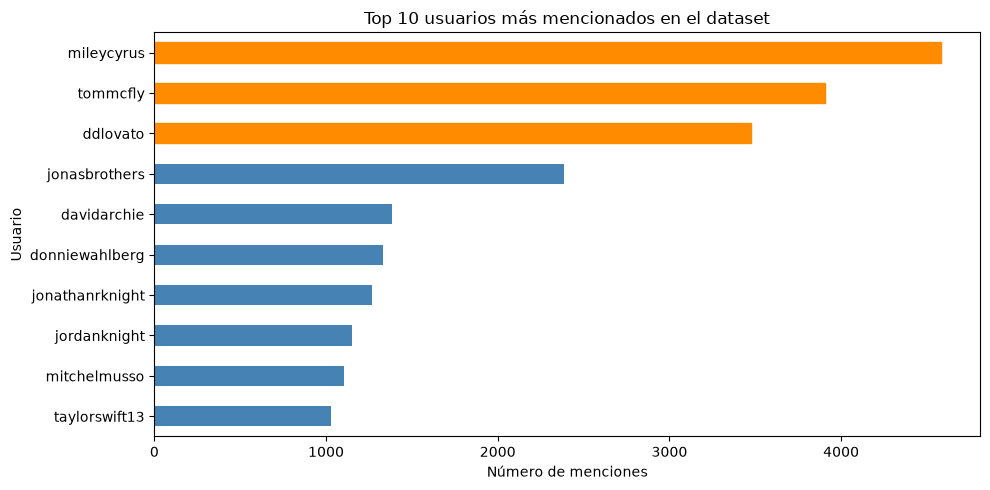

In [9]:
# Gráfica de barras horizontal del top 10
fig, ax = plt.subplots(figsize=(10, 5))
top_mencionados.sort_values().plot(kind='barh', ax=ax, color='steelblue')

# Resaltar el top 3 en otro color
for barra in ax.patches[-3:]:
    barra.set_color('darkorange')

ax.set_title('Top 10 usuarios más mencionados en el dataset')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('Usuario')
plt.tight_layout()
plt.savefig('outputs/top10_mencionados.png', dpi=150)
plt.show()

In [10]:
# Comparación: ¿quién publica más tweets?
print("=== Top 5 usuarios que más publican ===")
print(df['user'].value_counts().head(5))

=== Top 5 usuarios que más publican ===
user
lost_dog           549
webwoke            345
tweetpet           310
SallytheShizzle    281
VioletsCRUK        279
Name: count, dtype: int64


### Resultados

Alrededor del 46% de los tweets contienen al menos una mención. Los tres usuarios más mencionados fueron:

| # | Usuario | Menciones | Descripción |
|---|---|---|---|
| 1 | @mileycyrus | 4,580 | Miley Cyrus, cantante y actriz |
| 2 | @tommcfly | 3,904 | Tom Fletcher, integrante de la banda McFly |
| 3 | @ddlovato | 3,474 | Demi Lovato, cantante y actriz |

En el resto del top 10 también aparecen cuentas de artistas musicales, como los Jonas Brothers, David Archuleta y Taylor Swift.

Como comparación, se revisaron los usuarios que más tweets publicaron (lost_dog, webwoke, tweetpet). Ninguno de ellos aparece entre los más mencionados, por lo que publicar mucho y ser mencionado mucho no coinciden en este dataset. Por esa razón se mantuvo la definición de popularidad basada en menciones.

## 1.3 Construcción de los corpus

Para cada uno de los tres usuarios se armó un corpus con los tweets en los que es mencionado. Cada registro del corpus contiene:

- Content: el texto del tweet.
- Metadata: el ID del tweet, el timestamp de publicación y la longitud del tweet (calculada).

Antes de construirlos se hicieron dos ajustes al dataset. El primero fue convertir la columna `date`, que venía como texto (por ejemplo "Mon Apr 06 22:19:45 PDT 2009"), a un tipo fecha de pandas. Todos los registros están en la zona horaria PDT (hora del Pacífico), así que se removió ese texto y se asignó la zona horaria correspondiente.

Al revisar los tweets más largos de cada corpus se encontró que el archivo tiene codificación mixta: la mayoría de los tweets están en latin-1, pero algunos fueron guardados en UTF-8. Al leer todo el archivo como latin-1, los caracteres especiales de esos tweets aparecen como símbolos sin sentido (por ejemplo "â ââ") y su longitud aumenta, ya que en UTF-8 un carácter puede ocupar entre 2 y 4 bytes. Para corregirlo, cada tweet se volvió a interpretar como UTF-8 y, cuando no fue posible, se dejó como estaba.

El segundo fue decodificar las entidades HTML (`&quot;`, `&amp;`, `&lt;`, etc.) con la librería `html`, para que el contenido del tweet quede tal como lo escribió el usuario y la longitud calculada sea la real.

Para filtrar los tweets de cada usuario se usó la expresión regular `@usuario\b`, sin distinguir mayúsculas. El `\b` indica un límite de palabra, de modo que solo se incluyen menciones exactas al usuario y no a otras cuentas cuyo nombre empiece con las mismas letras.

In [17]:
import html

# Convertir la fecha de texto a datetime
# Formato original: "Mon Apr 06 22:19:45 PDT 2009"
df['timestamp'] = pd.to_datetime(
    df['date'].str.replace(' PDT', '', regex=False),
    format='%a %b %d %H:%M:%S %Y'
).dt.tz_localize('America/Los_Angeles')

# Corregir tweets que estaban en UTF-8 y se leyeron como latin-1
def corregir_codificacion(texto):
    try:
        return texto.encode('latin-1').decode('utf-8')
    except UnicodeError:
        # No es UTF-8 válido: se deja el texto original
        return texto

df['content'] = df['text'].map(corregir_codificacion)
print(f"Tweets con codificación corregida: {(df['content'] != df['text']).sum():,}")

# Decodificar entidades HTML (&quot; -> ", &amp; -> &, etc.)
df['content'] = df['content'].map(html.unescape)

# Tweets con caracteres que se perdieron en el dataset original
perdidos = df['content'].str.contains('\ufffd', regex=False).sum()
print(f"Tweets con caracteres irrecuperables (�): {perdidos:,}")

print("\nRango de fechas del dataset:")
print("  Desde:", df['timestamp'].min())
print("  Hasta:", df['timestamp'].max())

Tweets con codificación corregida: 13,251
Tweets con caracteres irrecuperables (�): 4,051

Rango de fechas del dataset:
  Desde: 2009-04-06 22:19:45-07:00
  Hasta: 2009-06-25 10:28:31-07:00


In [12]:
# Revisar cómo son los IDs duplicados
duplicados = df[df['id'].duplicated(keep=False)].sort_values('id')
print(duplicados[['id', 'target', 'user', 'content']].head(6))

# ¿Todos los duplicados tienen etiquetas de sentimiento distintas?
etiquetas_por_id = duplicados.groupby('id')['target'].nunique()
print(f"\nIDs duplicados con sentimiento distinto: {(etiquetas_por_id == 2).mean():.0%}")

                id  target         user  \
213     1467863684       0     DjGundam   
800261  1467863684       4     DjGundam   
800300  1467880442       4      iCalvin   
275     1467880442       0      iCalvin   
989     1468053611       0  mariejamora   
801280  1468053611       4  mariejamora   

                                                                                                                                     content  
213     Awwh babs... you look so sad underneith that shop entrance of "Yesterday's Musik"  O-: I like the look of the new transformer movie   
800261  Awwh babs... you look so sad underneith that shop entrance of "Yesterday's Musik"  O-: I like the look of the new transformer movie   
800300                                      Haven't tweeted nearly all day  Posted my website tonight, hopefully that goes well  Night time!  
275                                         Haven't tweeted nearly all day  Posted my website tonight, hopefully that goes wel

In [13]:
top3 = ['mileycyrus', 'tommcfly', 'ddlovato']

def construir_corpus(usuario, datos):
    """Devuelve un DataFrame con los tweets que mencionan al usuario,
    con su contenido y metadatos (ID, timestamp y longitud)."""
    patron = rf'@{usuario}\b'
    filtro = datos['content'].str.contains(patron, case=False, regex=True)

    corpus = datos.loc[filtro, ['id', 'timestamp', 'content']].copy()

    # Eliminar tweets duplicados (mismo ID)
    corpus = corpus.drop_duplicates(subset='id', keep='first')

    # Metadato calculado: longitud del tweet en caracteres
    corpus['length'] = corpus['content'].str.len()

    # Ordenar columnas: contenido primero, luego metadatos
    corpus = corpus[['content', 'id', 'timestamp', 'length']].reset_index(drop=True)
    return corpus

# Construir un corpus por cada usuario
corpus = {usuario: construir_corpus(usuario, df) for usuario in top3}

for usuario, c in corpus.items():
    print(f"@{usuario}: {len(c):,} tweets")

@mileycyrus: 4,544 tweets
@tommcfly: 3,884 tweets
@ddlovato: 3,455 tweets


In [14]:
for usuario, c in corpus.items():
    print(f"\n===== Corpus de @{usuario} =====")
    display(c.head(5))


===== Corpus de @mileycyrus =====


,content,id,timestamp,length
0,@mileycyrus hahaha dont be like that one time in NY when you got 30 mins of sleep then got sick love you!!,1468063101,2009-04-06 23:30:57-07:00,107
1,"@mileycyrus i have the same problem, but it's 4:43 here... let's see if counting works..1234...56 57 58... 132 133 134... no z's for me!",1468286517,2009-04-07 00:45:20-07:00,137
2,@mileycyrus I guess counting sheep didn't work Hope you get some sleep!,1468297110,2009-04-07 00:49:07-07:00,72
3,@mileycyrus I would too if it meant spending a day in heaven w/my mom and getting to see her again.,1468298918,2009-04-07 00:49:44-07:00,100
4,@mileycyrus AWWW u seriously have the cutest dog Miley! Sorry your not with her now Hope u get some sleep! xoxo,1468318249,2009-04-07 00:56:41-07:00,112



===== Corpus de @tommcfly =====


,content,id,timestamp,length
0,@tommcfly hey saw u guys play @ pushover..didn't get 2 meet u tho cuz of th HUGE line i was very upset ='( lol..a msg would make up 4 it!,1468210813,2009-04-07 00:19:09-07:00,138
1,@tommcfly Good morning Tom! Why can't I send you a message? This is too short for the question I have Well to bad for me I guess..,1468233211,2009-04-07 00:26:52-07:00,131
2,@tommcfly did you know that johnsons baby use animals like cute bunnies to test their products?,1468391638,2009-04-07 01:23:07-07:00,96
3,"@dougiemcfly @tommcfly good morning guys, how are you all? You know, it's frustrating, I never get a reply",1468502040,2009-04-07 02:03:41-07:00,108
4,"@tommcfly hey, no chance of adding brighton or eastbourne to the UCAP tour? gutted im missing out this time round i love you guys!",1468618787,2009-04-07 02:46:02-07:00,131



===== Corpus de @ddlovato =====


,content,id,timestamp,length
0,@ddlovato @David_Henrie ummmmm i cant find it.,1467929230,2009-04-06 22:51:34-07:00,47
1,@ddlovato Do you hate us?? Please don't,1467953367,2009-04-06 22:58:30-07:00,40
2,@ddlovato Wish that i could see it.. Thats the downside of living in Sweden.. Good Luck anyway,1469661950,2009-04-07 07:02:58-07:00,96
3,"@ddlovato hey demi, wen are you and selena gonna do another video? i miss them",1469674492,2009-04-07 07:05:11-07:00,79
4,@ddlovato ahhhh i wish i could go to the dallas show...but i wont be near there then,1548280868,2009-04-17 20:31:31-07:00,85


In [15]:
# Guardar cada corpus en un CSV dentro de outputs/
for usuario, c in corpus.items():
    c.to_csv(f'outputs/corpus_{usuario}.csv', index=False, encoding='utf-8')

print("Corpus guardados en la carpeta outputs/")

Corpus guardados en la carpeta outputs/


In [18]:
# Revisar los tweets más largos de cada corpus
for usuario, c in corpus.items():
    print(f"\n===== @{usuario} =====")
    display(c.sort_values('length', ascending=False).head(2))


===== @mileycyrus =====


,content,id,timestamp,length
1825,@mileycyrus http://twitpic.com/4cykv - wow.. itï¿½s very very nice photo.. You look fantastic? Miley..pls following me..please... iï¿½m y ...,1685625400,2009-05-03 01:15:33-07:00,142
825,@mileycyrus u need to come to australia youd love it here! pleasseee add us to ur tour dates! i love you so much.words can't describe itâ¥,2049499335,2009-06-05 16:59:24-07:00,140



===== @tommcfly =====


,content,id,timestamp,length
851,"@tommcfly ×××?× ×××¨ ×××©×¨×?×! ×× ××? ×¤×××¨, ×?×ª×? ××××××? ××?××¡××¨×××, ××¨×××, ×?×¨×× ××× ×... ××? ××××¢×...",2049334696,2009-06-05 16:42:03-07:00,201
2417,"@tommcfly Tom! For you: http://www.twitpic.com/5v181 and http://www.twitpic.com/5v0x2 vï¿½, por favor! (mistura de inglï¿½s e portuguï¿½s) xD",1971954982,2009-05-30 08:15:14-07:00,144



===== @ddlovato =====


,content,id,timestamp,length
1374,@ddlovato Hey Demi xD Iï¿½m from Germany and a big fan of you ^^ at which airport are you ?Oh my gosh canï¿½t believe that youï¿½re in Germany,1553208601,2009-04-18 13:39:25-07:00,143
2969,"@ddlovato Go Demi ! You're on trending topics ;)! â¥ Please come to Finland I love you and just gotta say your albums cover, wow, amazing.",2048801913,2009-06-05 15:47:53-07:00,140


### Resultados

Se construyeron los tres corpus con la siguiente cantidad de tweets:

| Usuario | Tweets en el corpus | Longitud promedio |
|---|---|---|
| @mileycyrus | 4,544 | 84.4 caracteres |
| @tommcfly | 3,884 | 86.0 caracteres |
| @ddlovato | 3,455 | 86.9 caracteres |

Estas cantidades son menores que el conteo de menciones de la sección anterior. En ese conteo cada mención sumaba por separado, así que un tweet que menciona dos veces al mismo usuario contaba doble, mientras que en el corpus cuenta como un solo registro. Además, se eliminaron los tweets con ID duplicado.

La revisión de los duplicados mostró que el 100% corresponde al mismo tweet registrado dos veces con etiquetas de sentimiento distintas. Como en este problema no se utiliza el sentimiento, se conservó solo una copia de cada uno.

La longitud promedio en los tres corpus (entre 84.4 y 86.9 caracteres) es mayor que el promedio general del dataset (74 caracteres).

Después de corregir la codificación, la longitud máxima en los corpus de @mileycyrus y @ddlovato es de 138 caracteres. En el corpus de @tommcfly se mantiene un tweet de 201 caracteres, escrito en hebreo, cuyo texto quedó dañado desde el dataset original (parte de sus caracteres fueron reemplazados por "?"), por lo que no fue posible recuperarlo. Se decidió mantenerlo en el corpus, ya que al estar en otro idioma no aporta palabras al análisis de contexto que se realiza en la siguiente sección.

In [16]:
corpus['tommcfly'].sort_values('length', ascending=False).head(3)

,content,id,timestamp,length
851,"@tommcfly ×××?× ×××¨ ×××©×¨×?×! ×× ××? ×¤×××¨, ×?×ª×? ××××××? ××?××¡××¨×××, ××¨×××, ×?×¨×× ××× ×... ××? ××××¢×...",2049334696,2009-06-05 16:42:03-07:00,201
2417,"@tommcfly Tom! For you: http://www.twitpic.com/5v181 and http://www.twitpic.com/5v0x2 vï¿½, por favor! (mistura de inglï¿½s e portuguï¿½s) xD",1971954982,2009-05-30 08:15:14-07:00,144
1267,"@tommcfly afternoon without internet, evening withuot twitter... really hard day, u understand me? â ââthe new pool..studio seems nice ;)",2197964579,2009-06-16 15:25:52-07:00,144


## 1.4 Preprocesamiento y extracción de contexto

Para responder por qué se menciona a cada usuario, se analizaron las palabras que aparecen alrededor de la mención. Se definió como contexto una ventana de 5 palabras antes y 5 palabras después de cada mención. Se eligió este tamaño porque los tweets son cortos (alrededor de 85 caracteres en promedio en los corpus), por lo que una ventana de 5 palabras cubre la mayor parte del mensaje sin incluir palabras demasiado alejadas de la mención.

El preprocesamiento se realizó en el siguiente orden:

1. Limpieza del texto con expresiones regulares.
2. Extracción de la ventana de contexto alrededor de la mención.
3. Remoción de stopwords.
4. Lematización y stemming.
5. Conteo de frecuencias para obtener el top 10 de cada usuario.

In [19]:
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from collections import Counter

# Descargar los recursos necesarios (solo la primera vez)
nltk.download('stopwords')                        # listas de stopwords
nltk.download('wordnet')                          # diccionario para lematizar
nltk.download('omw-1.4')                          # complemento de wordnet
nltk.download('averaged_perceptron_tagger_eng')   # etiquetador gramatical (POS)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\luisi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\luisi\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\luisi\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\luisi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

### Limpieza del texto

La limpieza se hizo con expresiones regulares, en este orden:

| Paso | Expresión regular | Qué hace |
|---|---|---|
| 1 | `.lower()` | Convierte todo a minúsculas |
| 2 | `https?://\S+\|www\.\S+` | Elimina URLs |
| 3 | `@usuario\b` | Reemplaza la mención al usuario analizado por la marca `usrtarget`, para ubicarla después |
| 4 | `@\w+` | Elimina las menciones a otros usuarios |
| 5 | `'` | Elimina apóstrofes, de modo que "don't" queda como "dont" |
| 6 | `[^a-z\s]` | Reemplaza por espacio todo lo que no sea letra (números, signos, emojis, caracteres de otros idiomas) |
| 7 | `(\w)\1{2,}` | Reduce letras repetidas 3 o más veces a solo 2 ("sooooo" pasa a "soo") |

El paso 3 es necesario para la extracción de contexto: la mención se conserva como marca para saber en qué posición del tweet está, y las palabras de la ventana se cuentan a partir de ella.

In [20]:
def limpiar_tweet(texto, usuario):
    """Limpia el tweet y devuelve una lista de palabras.
    La mención al usuario analizado se reemplaza por 'usrtarget'."""
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)   # URLs
    texto = re.sub(rf'@{usuario}\b', ' usrtarget ', texto)  # mención objetivo
    texto = re.sub(r'@\w+', ' ', texto)                     # otras menciones
    texto = texto.replace("'", '')                          # apóstrofes
    texto = re.sub(r'[^a-z\s]', ' ', texto)                 # solo letras
    texto = re.sub(r'(\w)\1{2,}', r'\1\1', texto)           # letras repetidas
    return texto.split()

# Prueba con un tweet de cada corpus
for usuario, c in corpus.items():
    ejemplo = c['content'].iloc[0]
    print(f"Original: {ejemplo}")
    print(f"Limpio:   {limpiar_tweet(ejemplo, usuario)}\n")

Original: @mileycyrus hahaha dont be like that one time in NY when you got 30 mins of sleep then got sick  love you!!
Limpio:   ['usrtarget', 'hahaha', 'dont', 'be', 'like', 'that', 'one', 'time', 'in', 'ny', 'when', 'you', 'got', 'mins', 'of', 'sleep', 'then', 'got', 'sick', 'love', 'you']

Original: @tommcfly hey saw u guys play @ pushover..didn't get 2 meet u tho cuz of th HUGE line  i was very upset ='( lol..a msg would make up 4 it!
Limpio:   ['usrtarget', 'hey', 'saw', 'u', 'guys', 'play', 'pushover', 'didnt', 'get', 'meet', 'u', 'tho', 'cuz', 'of', 'th', 'huge', 'line', 'i', 'was', 'very', 'upset', 'lol', 'a', 'msg', 'would', 'make', 'up', 'it']

Original: @ddlovato @David_Henrie ummmmm i cant find it. 
Limpio:   ['usrtarget', 'umm', 'i', 'cant', 'find', 'it']



In [21]:
VENTANA = 5  # palabras antes y después de la mención

def extraer_contexto(palabras, ventana=VENTANA):
    """Devuelve las palabras que están a una distancia máxima de 'ventana'
    de cualquier mención al usuario (sin incluir la mención)."""
    posiciones = [i for i, p in enumerate(palabras) if p == 'usrtarget']
    indices = set()
    for pos in posiciones:
        inicio = max(0, pos - ventana)
        fin = min(len(palabras), pos + ventana + 1)
        indices.update(range(inicio, fin))
    return [palabras[i] for i in sorted(indices) if palabras[i] != 'usrtarget']

# Prueba
ejemplo = corpus['mileycyrus']['content'].iloc[0]
limpio = limpiar_tweet(ejemplo, 'mileycyrus')
print("Palabras del tweet:", limpio)
print("Contexto extraído: ", extraer_contexto(limpio))

Palabras del tweet: ['usrtarget', 'hahaha', 'dont', 'be', 'like', 'that', 'one', 'time', 'in', 'ny', 'when', 'you', 'got', 'mins', 'of', 'sleep', 'then', 'got', 'sick', 'love', 'you']
Contexto extraído:  ['hahaha', 'dont', 'be', 'like', 'that']


### Remoción de stopwords

Se utilizó la lista de stopwords en inglés de NLTK. Como en la limpieza se eliminaron los apóstrofes, a la lista se le agregaron también sus versiones sin apóstrofe (por ejemplo "dont", "wont", "isnt"), ya que de lo contrario no se habrían eliminado.

Al revisar los primeros resultados se observó que la lista de NLTK no cubre el lenguaje informal de Twitter, por lo que se agregaron manualmente los siguientes grupos:

- Abreviaturas y contracciones: im, u, ur, cant, thats, ive, youre, id, amp, x, xx, lol, lmao, xd, xo, xoxo.
- Saludos e interjecciones: hey, hi, hello, oh, ohh, ah, aw, aww, wow, omg, yay, ya, yeah, ok, okay.
- Verbos modales y palabras de relleno: could, would, might, must, shall, really, well, also, even, still, yes, no.
- Los verbos get, got y go, que son muy frecuentes pero no indican un tema.

Las risas se eliminaron con una expresión regular en lugar de una lista, ya que aparecen con muchas variantes (haha, hahaha, hehe, lool, etc.). La expresión `^(ha|he|hah|ah|lo)+h?$|^a+w+$|^x+o*x*$` identifica palabras formadas solo por repeticiones de esas sílabas, además de variantes de "aww" y "xoxo".

Por último, para cada usuario se eliminaron las palabras que forman su propio nombre (por ejemplo "miley" y "cyrus" en el corpus de @mileycyrus), ya que repiten la información de la mención y no explican el motivo por el que se le cita.

In [27]:
# Stopwords de NLTK + versiones sin apóstrofe
stop_words = set(stopwords.words('english'))
stop_words |= {p.replace("'", '') for p in stop_words}

# Abreviaturas y contracciones
stop_words |= {'im', 'u', 'ur', 'cant', 'thats', 'ive', 'youre', 'id',
               'amp', 'x', 'xx', 'lol', 'lmao', 'xd', 'xo', 'xoxo'}

# Saludos e interjecciones
stop_words |= {'hey', 'hi', 'hello', 'oh', 'ohh', 'ah', 'aw', 'aww',
               'wow', 'omg', 'yay', 'ya', 'yeah', 'ok', 'okay'}

# Verbos modales y palabras de relleno
stop_words |= {'could', 'would', 'might', 'must', 'shall', 'really',
               'well', 'also', 'even', 'still', 'yes', 'no'}

# Verbos muy frecuentes sin tema
stop_words |= {'get', 'got', 'go'}

# Expresión regular para risas y variantes (haha, hehe, lool, awww, xoxo...)
patron_risa = re.compile(r'^(ha|he|hah|ah|lo)+h?$|^a+w+$|^x+o*x*$')

# Nombre propio de cada usuario
nombres_usuario = {
    'mileycyrus': {'miley', 'cyrus'},
    'tommcfly':   {'tom', 'mcfly'},
    'ddlovato':   {'demi', 'lovato'},
}

print(f"Total de stopwords: {len(stop_words)}")

# Prueba del patrón de risas
for p in ['haha', 'hahahah', 'hehe', 'lool', 'awww', 'xoxo', 'hate', 'hello']:
    print(f"{p:10} -> {'risa' if patron_risa.match(p) else 'se conserva'}")

Total de stopwords: 281
haha       -> risa
hahahah    -> risa
hehe       -> risa
lool       -> se conserva
awww       -> risa
xoxo       -> se conserva
hate       -> se conserva
hello      -> se conserva


### Lematización y stemming

Ambas técnicas reducen las palabras a una forma base, pero funcionan de manera distinta:

- La lematización usa un diccionario (WordNet) y devuelve una palabra real. Para que funcione correctamente necesita saber la categoría gramatical de la palabra, por ejemplo, "loving" como verbo se convierte en "love". Por eso, antes de lematizar, cada palabra se etiquetó con `nltk.pos_tag`.
- El stemming (algoritmo de Porter) corta los sufijos siguiendo reglas fijas. Es más agresivo y agrupa más variantes, pero el resultado muchas veces no es una palabra real (por ejemplo, "please" queda como "pleas").

Se aplicaron ambas técnicas de forma secuencial: primero se lematizó cada palabra y luego se aplicó stemming sobre el lema. Las frecuencias se contaron por raíz (stem), para agrupar la mayor cantidad de variantes. Para mostrar los resultados, cada raíz se representó con su lema más frecuente, de modo que en el top 10 y en el wordcloud aparezcan palabras legibles.

In [23]:
lematizador = WordNetLemmatizer()
stemmer = PorterStemmer()

def categoria_wordnet(etiqueta_pos):
    """Convierte la etiqueta de nltk.pos_tag al formato de WordNet."""
    if etiqueta_pos.startswith('J'):
        return wordnet.ADJ
    elif etiqueta_pos.startswith('V'):
        return wordnet.VERB
    elif etiqueta_pos.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

# Comparación con algunas palabras de ejemplo
palabras_ejemplo = ['loving', 'please', 'movies', 'awesome', 'replied', 'wishes', 'coming']
etiquetadas = nltk.pos_tag(palabras_ejemplo)

comparacion = pd.DataFrame([
    {'palabra': p,
     'POS': pos,
     'lema': lematizador.lemmatize(p, categoria_wordnet(pos)),
     'stem': stemmer.stem(p)}
    for p, pos in etiquetadas
])
comparacion

,palabra,POS,lema,stem
0,loving,VBG,love,love
1,please,NN,please,pleas
2,movies,NNS,movie,movi
3,awesome,VBP,awesome,awesom
4,replied,JJ,replied,repli
5,wishes,NNS,wish,wish
6,coming,VBG,come,come


In [30]:
def procesar_corpus(df_corpus, usuario):
    """Aplica limpieza, contexto, stopwords, lematización y stemming.
    Devuelve el conteo por raíz, el lema representativo de cada raíz
    y el tamaño del vocabulario en cada etapa."""
    conteo_stems = Counter()
    lemas_por_stem = {}
    vocab = {'original': set(), 'lematizado': set(), 'stemming': set()}
    excluir = stop_words | nombres_usuario[usuario]

    for texto in df_corpus['content']:
        palabras = limpiar_tweet(texto, usuario)
        contexto = extraer_contexto(palabras)

        # Remover stopwords, risas y palabras de una sola letra
        contexto = [p for p in contexto
                    if p not in excluir and len(p) > 1 and not patron_risa.match(p)]

        for palabra, pos in nltk.pos_tag(contexto):
            lema = lematizador.lemmatize(palabra, categoria_wordnet(pos))
            if lema in excluir:
                continue
            stem = stemmer.stem(lema)

            vocab['original'].add(palabra)
            vocab['lematizado'].add(lema)
            vocab['stemming'].add(stem)

            conteo_stems[stem] += 1
            lemas_por_stem.setdefault(stem, Counter())[lema] += 1

    # Representar cada raíz con su lema más frecuente
    representante = {s: c.most_common(1)[0][0] for s, c in lemas_por_stem.items()}
    return conteo_stems, representante, vocab

resultados = {}
for usuario, c in corpus.items():
    resultados[usuario] = procesar_corpus(c, usuario)
    print(f"@{usuario} procesado")

@mileycyrus procesado
@tommcfly procesado
@ddlovato procesado


In [31]:
tabla_vocab = pd.DataFrame({
    f'@{usuario}': {
        'Palabras de contexto': sum(conteo.values()),
        'Vocabulario original': len(vocab['original']),
        'Después de lematizar': len(vocab['lematizado']),
        'Después de stemming': len(vocab['stemming']),
    }
    for usuario, (conteo, _, vocab) in resultados.items()
}).T

tabla_vocab

,Palabras de contexto,Vocabulario original,Después de lematizar,Después de stemming
@mileycyrus,9694,2254,2032,1927
@tommcfly,7887,1934,1723,1645
@ddlovato,7348,1944,1757,1663


In [32]:
top10 = {}
for usuario, (conteo, representante, _) in resultados.items():
    top10[usuario] = {representante[stem]: n for stem, n in conteo.most_common(10)}

tabla_top10 = pd.DataFrame({
    f'@{usuario}': [f"{palabra} ({n})" for palabra, n in palabras.items()]
    for usuario, palabras in top10.items()
}, index=range(1, 11))

tabla_top10

,@mileycyrus,@tommcfly,@ddlovato
1,love (375),say (184),love (266)
2,vote (278),love (152),wish (169)
3,good (185),please (152),come (120)
4,come (171),good (147),please (108)
5,hope (156),come (134),hope (107)
6,please (115),like (107),wait (99)
7,luck (105),miss (104),see (97)
8,see (96),reply (97),good (96)
9,wish (93),guy (94),awesome (90)
10,like (92),think (94),want (80)


### Resultados

La lematización y el stemming redujeron el vocabulario de cada corpus:

| Usuario | Vocabulario original | Después de lematizar | Después de stemming |
|---|---|---|---|
| @mileycyrus | 2,254 | 2,032 | 1,927 |
| @tommcfly | 1,934 | 1,723 | 1,645 |
| @ddlovato | 1,944 | 1,757 | 1,663 |

En los tres casos, la lematización redujo el vocabulario en alrededor de un 10%, y el stemming lo redujo en alrededor de un 5% adicional.

Las 10 palabras más frecuentes en el contexto de cada mención fueron:

| # | @mileycyrus | @tommcfly | @ddlovato |
|---|---|---|---|
| 1 | love (375) | say (184) | love (266) |
| 2 | vote (278) | love (152) | wish (169) |
| 3 | good (185) | please (152) | come (120) |
| 4 | come (171) | good (147) | please (108) |
| 5 | hope (156) | come (134) | hope (107) |
| 6 | please (115) | like (107) | wait (99) |
| 7 | luck (105) | miss (104) | see (97) |
| 8 | see (96) | reply (97) | good (96) |
| 9 | wish (93) | guy (94) | awesome (90) |
| 10 | like (92) | think (94) | want (80) |

## 1.5 Wordclouds

Con las 10 palabras más frecuentes del contexto de cada usuario se generó un wordcloud. El tamaño de cada palabra es proporcional a su frecuencia. Se utilizó el método `generate_from_frequencies` de la librería wordcloud, que construye la nube a partir de los conteos ya calculados en lugar de volver a procesar el texto.

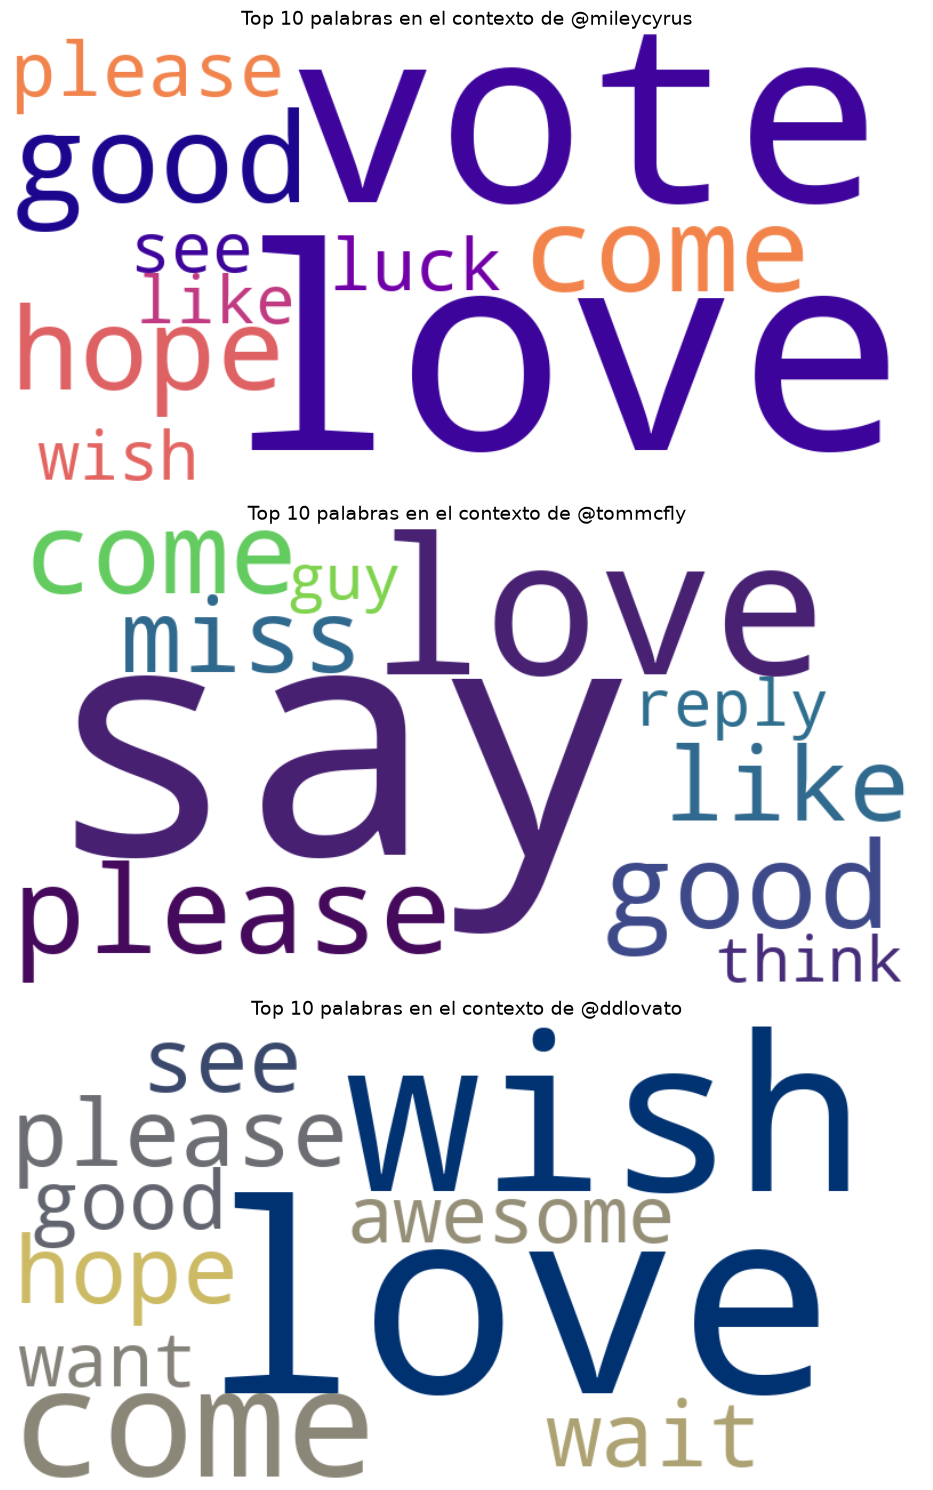

In [33]:
from wordcloud import WordCloud

colores = {'mileycyrus': 'plasma', 'tommcfly': 'viridis', 'ddlovato': 'cividis'}

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for ax, (usuario, palabras) in zip(axes, top10.items()):
    nube = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colores[usuario],
        prefer_horizontal=1.0,
        random_state=42
    ).generate_from_frequencies(palabras)

    # Guardar cada wordcloud por separado
    nube.to_file(f'outputs/wordcloud_{usuario}.png')

    ax.imshow(nube, interpolation='bilinear')
    ax.set_title(f'Top 10 palabras en el contexto de @{usuario}', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/wordclouds_top3.png', dpi=150)
plt.show()

## 1.6 ¿Por qué se cita a cada usuario?

Las palabras individuales del top 10 no son suficientes para explicar el motivo de las menciones. Por ejemplo, "come" aparece en los tres usuarios, pero no indica a qué se refiere. Por esto, para las palabras más relevantes de cada usuario se buscaron las frases de tres palabras más frecuentes que comienzan con ellas, utilizando el texto original del tweet (sin limpiar), para conservar el sentido completo.

In [34]:
def frases_frecuentes(df_corpus, palabra, largo=3, top=5):
    """Devuelve las frases de 'largo' palabras más frecuentes que
    comienzan con 'palabra' (incluye variantes como vote/voted)."""
    conteo = Counter()
    for texto in df_corpus['content'].str.lower():
        texto = re.sub(r'@\w+|https?://\S+', ' ', texto)   # quitar menciones y URLs
        tokens = re.findall(r"[a-z']+", texto)
        for i, t in enumerate(tokens):
            if t.startswith(palabra) and i + largo <= len(tokens):
                conteo[' '.join(tokens[i:i + largo])] += 1
    return conteo.most_common(top)

palabras_clave = {
    'mileycyrus': ['vote', 'hope', 'luck', 'come'],
    'tommcfly':   ['say', 'please', 'reply', 'come'],
    'ddlovato':   ['wish', 'wait', 'come', 'please'],
}

for usuario, palabras in palabras_clave.items():
    print(f"\n========== @{usuario} ==========")
    for palabra in palabras:
        frases = frases_frecuentes(corpus[usuario], palabra)
        print(f"\n'{palabra}':")
        for frase, n in frases:
            print(f"   {n:4}  {frase}")


========== @mileycyrus ==========

'vote':
     79  voted for you
     70  vote for you
     10  vote for u
      8  voted for u
      7  vote for now

'hope':
     51  hope you win
     20  hope you have
     18  hope you feel
     16  hope u win
      7  hope to see

'luck':
     15  luck at the
     12  luck pray for
      5  luck i hope
      4  luck miley i
      4  luck for tonight

'come':
     25  come to brazil
     13  come to australia
     11  come to argentina
     11  come to scotland
     10  come to the

========== @tommcfly ==========

'say':
     60  say hi to
     52  say happy birthday
     16  say hi if
     11  say hola mexicanas
      9  say that not

'please':
     42  please please please
     21  please please my
     21  please my hand
     20  please answer me
     20  please say hi

'reply':
     25  reply to me
      9  reply from you
      8  reply me i'm
      5  reply when ppl
      4  reply me please

'come':
     35  come back to
     21  come back s

In [35]:
# Cantidad de tweets de cada corpus que contienen ciertos términos
terminos = {
    'mileycyrus': ['award', 'mtv', 'movie', 'win', 'hannah'],
    'tommcfly':   ['brazil', 'reply', 'show', 'tour', 'gig'],
    'ddlovato':   ['concert', 'album', 'jonas', 'tour', 'sonny'],
}

for usuario, lista in terminos.items():
    textos = corpus[usuario]['content'].str.lower()
    print(f"\n@{usuario} ({len(textos):,} tweets)")
    for t in lista:
        n = textos.str.contains(rf'\b{t}', regex=True).sum()
        print(f"   {t:10} {n:4} tweets ({n/len(textos):.1%})")


@mileycyrus (4,544 tweets)
   award       234 tweets (5.1%)
   mtv         146 tweets (3.2%)
   movie       216 tweets (4.8%)
   win         215 tweets (4.7%)
   hannah      113 tweets (2.5%)

@tommcfly (3,884 tweets)
   brazil      263 tweets (6.8%)
   reply       211 tweets (5.4%)
   show        184 tweets (4.7%)
   tour        114 tweets (2.9%)
   gig          57 tweets (1.5%)

@ddlovato (3,455 tweets)
   concert     115 tweets (3.3%)
   album       115 tweets (3.3%)
   jonas       109 tweets (3.2%)
   tour         92 tweets (2.7%)
   sonny        46 tweets (1.3%)


In [36]:
# Revisar si hay tweets con el mismo texto publicados varias veces
autores = df.drop_duplicates('id').set_index('id')['user']

for usuario, c in corpus.items():
    repeticiones = c['content'].value_counts()
    repetidos = repeticiones[repeticiones > 1]
    print(f"\n@{usuario}: {len(repetidos)} textos repetidos, "
          f"que suman {repetidos.sum()} tweets")

    # Los 2 textos más repetidos y quién los publicó
    for texto, n in repeticiones.head(2).items():
        ids = c.loc[c['content'] == texto, 'id']
        quien = autores.loc[ids].unique()
        print(f"   {n} veces, autor(es): {list(quien)}")
        print(f"   \"{texto[:90]}...\"")


@mileycyrus: 52 textos repetidos, que suman 194 tweets
   23 veces, autor(es): ['Jeff_Hardyfan']
   ""@mileycyrus"you are the best!!!! I love you  can you give me your e-mail???I want to writ..."
   18 veces, autor(es): ['sierrabardot']
   "@mileycyrus you can have a little  back. it's what you gave to me. you're an amazing perso..."

@tommcfly: 73 textos repetidos, que suman 254 tweets
   18 veces, autor(es): ['keren4562']
   "@tommcfly plz say "Happy Birthday Or , Roni & Mickey!" plz plz plz ..."
   16 veces, autor(es): ['keren4562']
   "@tommcfly plz say "Happy Birthday Or , Roni & Mickey!" plz plz plz  x..."

@ddlovato: 34 textos repetidos, que suman 122 tweets
   19 veces, autor(es): ['treeksquad']
   "@ddlovato AJ RAFAEL (AWESOME MUSICIAN, FAMOUS ON YOUTUBE) COVERED YOUR SONG, DON'T FORGET...."
   11 veces, autor(es): ['Jamiescott19']
   "@ddlovato I want to be more than a fan i want to be a friend do you think that's possible ..."


### Resultados

**@mileycyrus**

Las palabras más frecuentes en el contexto de sus menciones fueron love, vote, good, hope y luck. Al revisar las frases, "vote" aparece principalmente como "voted for you" (79) y "vote for you" (70), y "hope" como "hope you win" (51) y "hope u win" (16). Además, "award" aparece en 234 tweets del corpus, "movie" en 216 y "mtv" en 146. En la palabra "luck", la frase más frecuente es "luck at the" (15), seguida en su mayoría de "awards" o "mtv movie". Con esto se concluye que a Miley Cyrus se le menciona principalmente para apoyarla en una premiación: sus seguidores le cuentan que votaron por ella y le desean suerte para ganar. También aparecen peticiones para que visite distintos países, como "come to brazil" (25) y "come to australia" (13).

**@tommcfly**

La palabra más frecuente fue "say", que aparece principalmente en "say hi to" (60) y "say happy birthday" (52). Sin embargo, al revisar los tweets repetidos se encontró que buena parte de las frases con "happy birthday" provienen de un mismo mensaje publicado muchas veces por un solo usuario. Las demás palabras del top 10 (please, reply, miss) aparecen en frases como "please answer me" (20), "reply to me" (25) y "miss you" (21). "Come" aparece sobre todo en "come back to" (35), y en esos casos la palabra siguiente más frecuente es Brazil. Brazil aparece en 263 tweets del corpus (6.8%). Se concluye que a Tom Fletcher se le menciona principalmente para pedirle que responda o salude a sus seguidores, y en segundo lugar para pedirle que regrese a Brasil.

**@ddlovato**

Las palabras más frecuentes fueron love, wish, come, please y hope. "Wish" aparece principalmente en "wish i could" (103) y "wish i was" (38), y al revisar la continuación, las más comunes son "go to", "be there" y "see you". "Wait" aparece sobre todo en "wait to see" (44) y "wait for your" (26). En el corpus, "concert" y "album" aparecen en 115 tweets cada una. Se concluye que a Demi Lovato se le menciona principalmente para expresarle el deseo de verla o asistir a sus eventos y la expectativa por su música y presentaciones. La frase "please watch it" (20) no refleja un tema general, ya que corresponde a un mismo mensaje promocional publicado 19 veces por una sola cuenta.

**Limitación del análisis**

En los tres corpus hay tweets con el mismo texto publicados varias veces (entre 122 y 254 tweets por corpus). Estos tweets se conservaron porque tienen IDs distintos y son publicaciones reales, pero hacen que algunas frases aparezcan con más frecuencia de la que tendrían si cada mensaje se contara una sola vez.

## Conclusión del Problema 1

Los tres usuarios más mencionados del dataset son cuentas de artistas musicales: @mileycyrus (4,580 menciones), @tommcfly (3,904) y @ddlovato (3,474). En los tres casos, las menciones provienen de seguidores que les escriben directamente, pero el motivo principal es distinto para cada uno: en el caso de Miley Cyrus, el apoyo en una premiación; en el de Tom Fletcher, las peticiones de respuesta o saludo; y en el de Demi Lovato, el deseo de verla en persona.

Las palabras individuales del wordcloud permitieron identificar los temas, pero fue necesario revisar las frases completas para interpretar correctamente algunas de ellas, como "vote", "say" o "wish". Esta revisión también permitió detectar tweets repetidos que inflaban la frecuencia de ciertas palabras.

# Problema 2: Fruits and Vegetables Recognizer

## Introducción

En este problema se desarrolló un modelo de clasificación de imágenes basado en redes neuronales convolucionales (CNN) para distinguir entre distintos tipos de frutas y verduras. Se buscó que el modelo fuera robusto ante variaciones de tamaño, rotación e iluminación, para lo cual se aplicaron técnicas de data augmentation durante el entrenamiento.

Se utilizó el dataset Fruits and Vegetables Dataset de Kaggle, que contiene alrededor de 12,000 imágenes organizadas en 20 clases: 10 de frutas y 10 de verduras, cada una en versión fresca (Fresh) y podrida (Rotten). El dataset no incluye una división en conjuntos de entrenamiento, validación y prueba, por lo que esta se realizó como parte del preprocesamiento.

Se entrenaron y compararon tres arquitecturas de CNN distintas, con el fin de seleccionar la que obtuviera mejor desempeño sobre el conjunto de prueba.

Esta sección es independiente del Problema 1: puede ejecutarse después de reiniciar el kernel, sin necesidad de volver a cargar el dataset de tweets.

In [38]:
# Liberar la memoria usada por el Problema 1 
import gc

for variable in ['df', 'todas_menciones', 'corpus', 'resultados', 'autores']:
    if variable in globals():
        del globals()[variable]

gc.collect()
print("Memoria liberada")

Memoria liberada


In [39]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Semilla para que los resultados sean reproducibles
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

os.makedirs('outputs', exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Dispositivos disponibles:", tf.config.list_physical_devices())

TensorFlow: 2.21.0
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [40]:
RUTA_DATASET = 'archive/Fruits_Vegetables_Dataset(12000)'

registros = []
for categoria in ['Fruits', 'Vegetables']:
    ruta_cat = os.path.join(RUTA_DATASET, categoria)
    for clase in sorted(os.listdir(ruta_cat)):
        archivos = os.listdir(os.path.join(ruta_cat, clase))
        registros.append({
            'categoria': categoria,
            'clase': clase,
            'estado': 'Fresh' if clase.startswith('Fresh') else 'Rotten',
            'imagenes': len(archivos),
        })

inventario = pd.DataFrame(registros)
print(f"Total de imágenes: {inventario['imagenes'].sum():,}")
inventario

Total de imágenes: 12,000


,categoria,clase,estado,imagenes
0,Fruits,FreshApple,Fresh,612
1,Fruits,FreshBanana,Fresh,624
2,Fruits,FreshMango,Fresh,605
3,Fruits,FreshOrange,Fresh,609
4,Fruits,FreshStrawberry,Fresh,603
5,Fruits,RottenApple,Rotten,588
6,Fruits,RottenBanana,Rotten,576
7,Fruits,RottenMango,Rotten,593
8,Fruits,RottenOrange,Rotten,591
9,Fruits,RottenStrawberry,Rotten,596


## 2.1 Selección de clases

Se seleccionaron tres frutas y tres verduras:

| Categoría | Clases |
|---|---|
| Frutas | Manzana (Apple), Banana (Banana), Naranja (Orange) |
| Verduras | Zanahoria (Carrot), Papa (Potato), Pepino (Cucumber) |

El tomate se descartó porque, aunque el dataset lo clasifica como verdura, botánicamente es una fruta.

Se decidió trabajar únicamente con las imágenes de productos frescos, por tres razones:

1. El objetivo del problema es distinguir entre tipos de frutas y verduras, no determinar su estado.
2. Incluir las imágenes de productos podridos habría agregado una segunda variable al problema. Una manzana podrida y una banana podrida comparten características visuales (manchas oscuras, moho, cambios de textura) que no tienen relación con el tipo de producto.
3. El entrenamiento se realizó en CPU y fue necesario comparar tres arquitecturas, por lo que un conjunto de 6 clases permitió realizar más pruebas en un tiempo razonable.

Con esta selección se trabajó con 6 clases y un total de 3,688 imágenes, con entre 608 y 624 imágenes por clase. Las clases están balanceadas, por lo que no fue necesario aplicar técnicas de balanceo.

In [41]:
# Clases seleccionadas: carpeta original -> nombre final de la clase
clases_seleccionadas = {
    'Fruits/FreshApple':         'Apple',
    'Fruits/FreshBanana':        'Banana',
    'Fruits/FreshOrange':        'Orange',
    'Vegetables/FreshCarrot':    'Carrot',
    'Vegetables/FreshPotato':    'Potato',
    'Vegetables/FreshCucumber':  'Cucumber',
}

EXTENSIONES = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for carpeta, clase in clases_seleccionadas.items():
    ruta = os.path.join(RUTA_DATASET, carpeta)
    archivos = os.listdir(ruta)
    imagenes = [f for f in archivos if f.lower().endswith(EXTENSIONES)]
    otros = len(archivos) - len(imagenes)
    print(f"{clase:10} {len(imagenes):4} imágenes  |  otros archivos: {otros}")

Apple       612 imágenes  |  otros archivos: 0
Banana      624 imágenes  |  otros archivos: 0
Orange      609 imágenes  |  otros archivos: 0
Carrot      620 imágenes  |  otros archivos: 0
Potato      615 imágenes  |  otros archivos: 0
Cucumber    608 imágenes  |  otros archivos: 0


In [42]:
from PIL import Image

# Revisar tamaño y modo de color en una muestra de 50 imágenes por clase
muestra = []
for carpeta, clase in clases_seleccionadas.items():
    ruta = os.path.join(RUTA_DATASET, carpeta)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(EXTENSIONES)]
    for f in random.sample(archivos, min(50, len(archivos))):
        with Image.open(os.path.join(ruta, f)) as img:
            muestra.append({'clase': clase, 'ancho': img.width,
                            'alto': img.height, 'modo': img.mode})

muestra = pd.DataFrame(muestra)

print("Modos de color encontrados:")
print(muestra['modo'].value_counts(), "\n")
print("Estadísticas de tamaño (píxeles):")
print(muestra[['ancho', 'alto']].describe().round(0))

Modos de color encontrados:
modo
RGB    299
P        1
Name: count, dtype: int64 

Estadísticas de tamaño (píxeles):
        ancho    alto
count   300.0   300.0
mean    422.0   352.0
std     587.0   433.0
min     100.0   100.0
25%     224.0   224.0
50%     224.0   224.0
75%     390.0   322.0
max    4032.0  3024.0


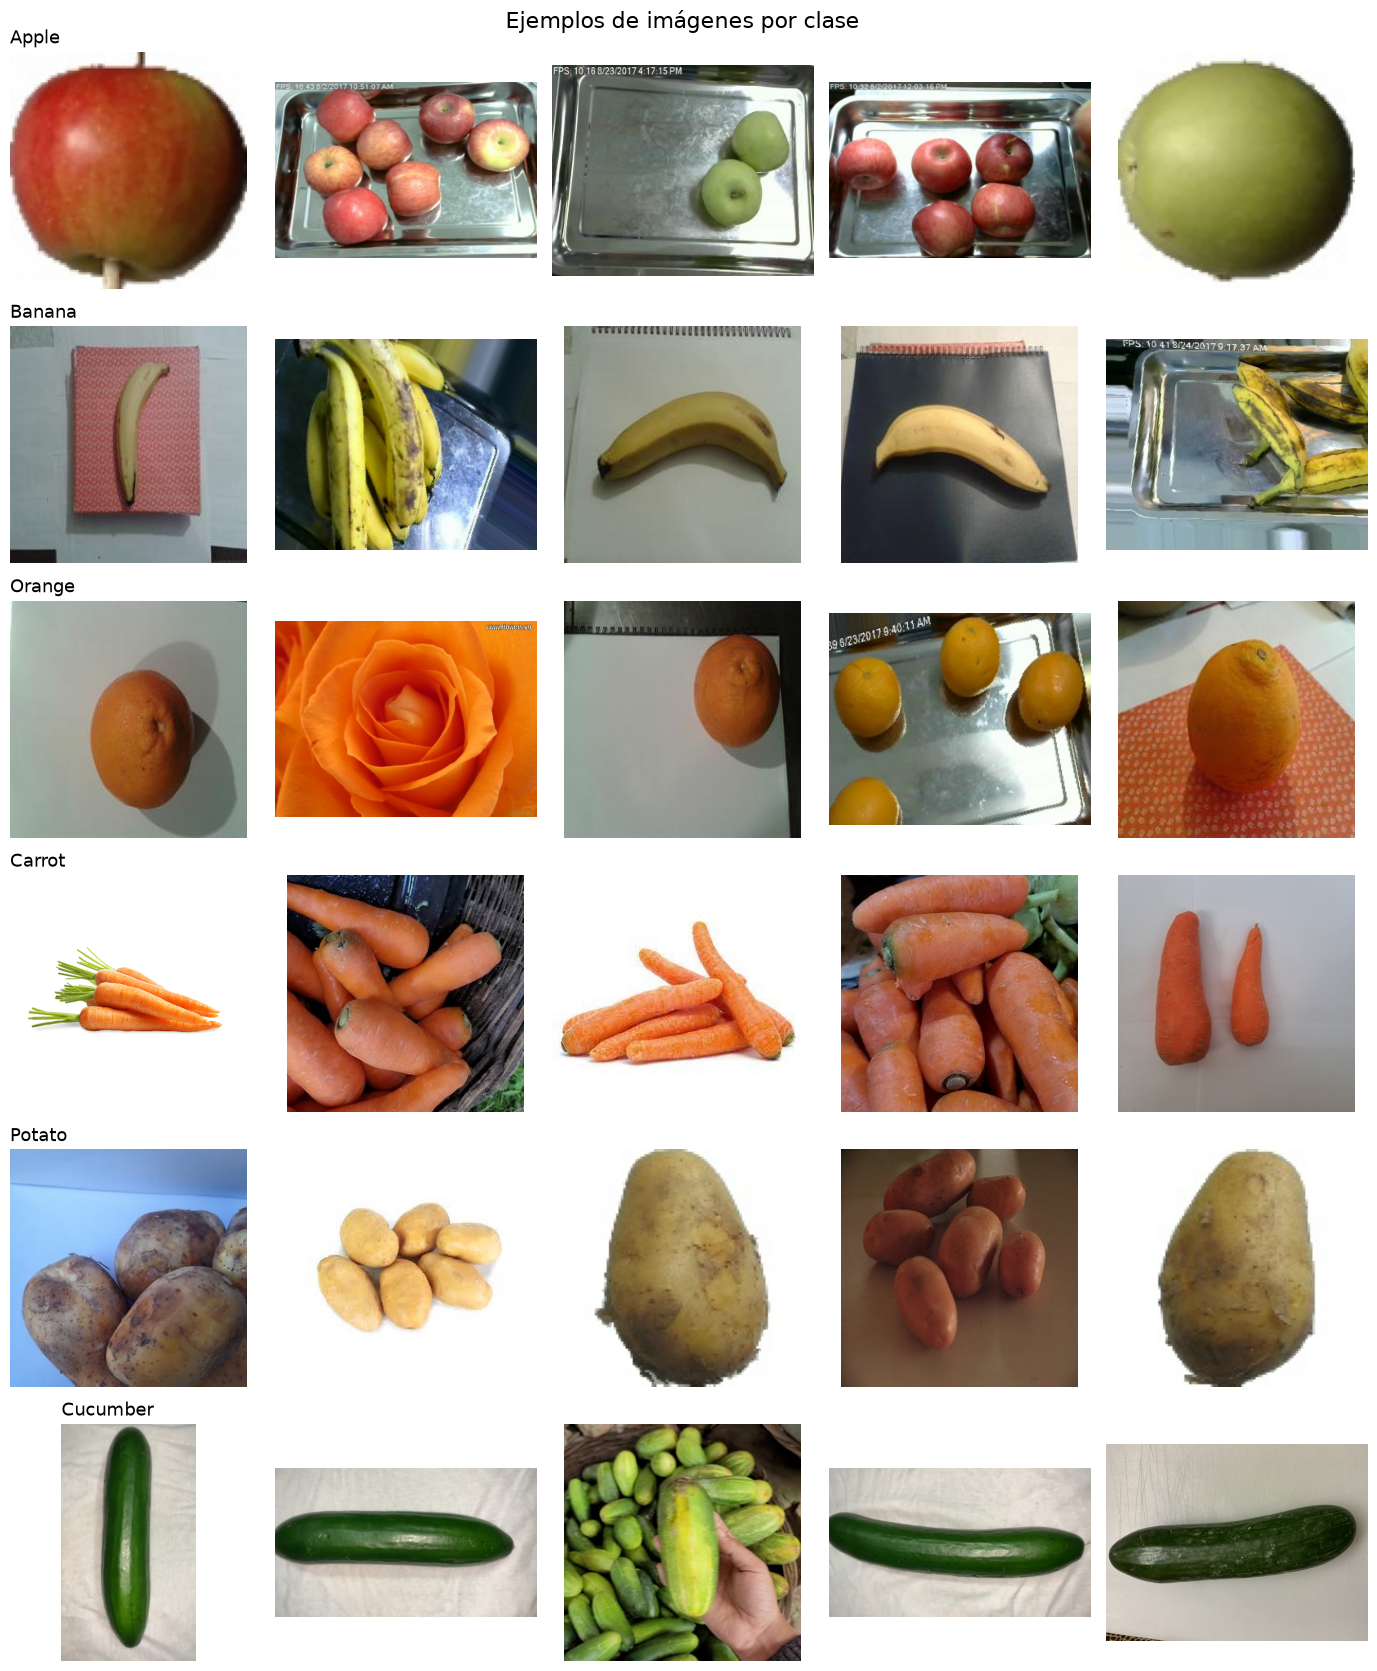

In [43]:
fig, axes = plt.subplots(len(clases_seleccionadas), 5, figsize=(14, 17))

for fila, (carpeta, clase) in enumerate(clases_seleccionadas.items()):
    ruta = os.path.join(RUTA_DATASET, carpeta)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(EXTENSIONES)]
    for col, f in enumerate(random.sample(archivos, 5)):
        img = Image.open(os.path.join(ruta, f))
        axes[fila, col].imshow(img)
        axes[fila, col].axis('off')
        if col == 0:
            axes[fila, col].set_title(clase, fontsize=13, loc='left')

plt.suptitle('Ejemplos de imágenes por clase', fontsize=16)
plt.tight_layout()
plt.savefig('outputs/ejemplos_clases.png', dpi=100)
plt.show()

## 2.2 División en entrenamiento, validación y prueba

Las imágenes se dividieron en tres conjuntos, de forma estratificada (la misma proporción en cada clase):

| Conjunto | Proporción | Uso |
|---|---|---|
| Entrenamiento | 70% | Ajustar los pesos de la red |
| Validación | 15% | Monitorear el entrenamiento, detectar sobreajuste y comparar arquitecturas |
| Prueba | 15% | Evaluación final del modelo seleccionado, con imágenes que no se usaron en ninguna decisión |

La función `flow_from_directory` de Keras lee las imágenes a partir de una estructura de carpetas en la que cada subcarpeta corresponde a una clase. Por esto, la división se realizó copiando las imágenes a una nueva carpeta `data_split` con la siguiente estructura:

    data_split/
    ├── train/  (Apple, Banana, Carrot, Cucumber, Orange, Potato)
    ├── val/    (mismas clases)
    └── test/   (mismas clases)

Las imágenes se copiaron en lugar de moverse, para conservar el dataset original sin cambios. La selección de imágenes de cada conjunto se hizo de forma aleatoria con una semilla fija, para que la división sea reproducible.

Al cargar las imágenes con `flow_from_directory` se detectó que el conjunto de entrenamiento tenía 3 imágenes menos que las copiadas. Al revisar las extensiones de los archivos se encontró que eran 3 imágenes en formato WEBP, un formato que `flow_from_directory` no reconoce y omite sin generar un error. Para no perder estas imágenes, durante la copia se convirtieron a formato JPG.

In [50]:
RUTA_SPLIT = 'data_split'
PROPORCION_TRAIN = 0.70
PROPORCION_VAL = 0.15   # el resto (15%) queda para test

# Formatos que flow_from_directory puede leer directamente
FORMATOS_KERAS = ('.jpg', '.jpeg', '.png', '.bmp')

# Si la carpeta ya existe, se elimina para evitar mezclar divisiones anteriores
if os.path.exists(RUTA_SPLIT):
    shutil.rmtree(RUTA_SPLIT)

conteo_split = []
convertidas = []
for carpeta, clase in clases_seleccionadas.items():
    ruta_origen = os.path.join(RUTA_DATASET, carpeta)
    imagenes = sorted(f for f in os.listdir(ruta_origen) if f.lower().endswith(EXTENSIONES))

    random.Random(SEMILLA).shuffle(imagenes)
    n_train = int(len(imagenes) * PROPORCION_TRAIN)
    n_val = int(len(imagenes) * PROPORCION_VAL)

    conjuntos = {
        'train': imagenes[:n_train],
        'val':   imagenes[n_train:n_train + n_val],
        'test':  imagenes[n_train + n_val:],
    }

    for conjunto, lista in conjuntos.items():
        ruta_destino = os.path.join(RUTA_SPLIT, conjunto, clase)
        os.makedirs(ruta_destino, exist_ok=True)
        for f in lista:
            origen = os.path.join(ruta_origen, f)
            if f.lower().endswith(FORMATOS_KERAS):
                shutil.copy2(origen, os.path.join(ruta_destino, f))
            else:
                # Convertir a JPG los formatos que Keras no lee (ej. .webp)
                nuevo_nombre = os.path.splitext(f)[0] + '.jpg'
                with Image.open(origen) as img:
                    img.convert('RGB').save(os.path.join(ruta_destino, nuevo_nombre), 'JPEG', quality=95)
                convertidas.append((conjunto, clase, f))

    conteo_split.append({'clase': clase, **{k: len(v) for k, v in conjuntos.items()}})

print(f"Imágenes convertidas a JPG: {len(convertidas)}")
for conjunto, clase, f in convertidas:
    print(f"   {conjunto}/{clase}/{f}")

tabla_split = pd.DataFrame(conteo_split).set_index('clase')
tabla_split.loc['Total'] = tabla_split.sum()
tabla_split

Imágenes convertidas a JPG: 3
   train/Banana/freshBanana (1).webp
   train/Carrot/freshCarrot (1).webp
   train/Potato/freshPotato (1).webp


,train,val,test
clase,,,
Apple,428,91,93
Banana,436,93,95
Orange,426,91,92
Carrot,434,93,93
Potato,430,92,93
Cucumber,425,91,92
Total,2579,551,558


## 2.3 Preprocesamiento

**Color o escala de grises**

Se decidió trabajar con imágenes a color (RGB, 3 canales). En este problema el color es una característica importante para distinguir las clases: la banana, la naranja y la zanahoria tienen colores característicos, y el pepino se distingue de la papa principalmente por su color verde. Al convertir a escala de grises se pierde esta información y el modelo tendría que depender solo de la forma y la textura. El costo de usar color es que la entrada tiene 3 canales en lugar de 1, lo cual solo afecta a la primera capa convolucional.

**Tamaño de las imágenes**

En una muestra de 300 imágenes se encontró que los tamaños varían entre 100×100 y 4032×3024 píxeles, con una mediana de 224×224. Todas las imágenes se redimensionaron a 128×128 píxeles. Se eligió este tamaño porque reduce aproximadamente a la tercera parte la cantidad de píxeles respecto a 224×224, lo que disminuye el tiempo de entrenamiento en CPU, y conserva suficiente detalle para distinguir la forma y la textura de cada producto. Las imágenes de menor tamaño (100×100) se amplían ligeramente.

También se encontró una imagen en modo de paleta (P) en lugar de RGB. No fue necesario tratarla por separado, ya que `flow_from_directory` convierte todas las imágenes a RGB al cargarlas.

**Normalización**

Los valores de los píxeles, que originalmente están entre 0 y 255, se dividieron entre 255 (`rescale=1./255`) para llevarlos al rango de 0 a 1. Con valores en una escala pequeña y uniforme, el entrenamiento de la red es más estable.

### Data augmentation

Para que el modelo fuera robusto ante variaciones de tamaño, rotación e iluminación, se aplicaron transformaciones aleatorias a las imágenes de entrenamiento con `ImageDataGenerator`. Cada vez que una imagen se usa en el entrenamiento, se le aplica una combinación distinta de transformaciones, así que el modelo prácticamente nunca ve la misma imagen dos veces.

| Transformación | Parámetro | Variación que simula |
|---|---|---|
| Rotación | `rotation_range=30` | Productos fotografiados en distintos ángulos (hasta ±30°) |
| Escalado | `zoom_range=0.2` | Productos más cerca o más lejos de la cámara (±20%) |
| Desplazamiento | `width_shift_range=0.1`, `height_shift_range=0.1` | Producto que no está centrado en la imagen (±10%) |
| Flip horizontal | `horizontal_flip=True` | Producto orientado hacia el lado contrario |
| Brillo | `brightness_range=[0.7, 1.3]` | Distintas condiciones de iluminación (±30%) |
| Ruido gaussiano | `preprocessing_function` | Fotos de menor calidad o con ruido del sensor de la cámara |

`ImageDataGenerator` no incluye una opción para agregar ruido, por lo que se implementó con una función propia que suma ruido gaussiano (media 0, desviación estándar de 10 en la escala de 0 a 255). Keras aplica esta función antes del `rescale`, por eso el ruido se define en la escala original de los píxeles.

Los espacios vacíos que quedan en la imagen después de rotarla o desplazarla se rellenaron con el color del píxel más cercano (`fill_mode='nearest'`).

Las imágenes de validación y prueba no se modificaron, solo se normalizaron, ya que estos conjuntos deben representar imágenes reales para medir correctamente el desempeño del modelo.

In [51]:
TAMANO_IMG = (128, 128)
BATCH_SIZE = 32

def agregar_ruido(imagen):
    """Agrega ruido gaussiano a la imagen (valores en escala 0-255)."""
    ruido = np.random.normal(loc=0.0, scale=10.0, size=imagen.shape)
    return np.clip(imagen + ruido, 0, 255)

# Generador de entrenamiento: normalización + data augmentation
generador_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    preprocessing_function=agregar_ruido
)

# Generador de validación y prueba: solo normalización
generador_eval = ImageDataGenerator(rescale=1./255)

In [52]:
train_data = generador_train.flow_from_directory(
    os.path.join(RUTA_SPLIT, 'train'),
    target_size=TAMANO_IMG,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEMILLA
)

val_data = generador_eval.flow_from_directory(
    os.path.join(RUTA_SPLIT, 'val'),
    target_size=TAMANO_IMG,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = generador_eval.flow_from_directory(
    os.path.join(RUTA_SPLIT, 'test'),
    target_size=TAMANO_IMG,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NOMBRES_CLASES = list(train_data.class_indices.keys())
NUM_CLASES = len(NOMBRES_CLASES)
print("\nÍndice de cada clase:", train_data.class_indices)

Found 2579 images belonging to 6 classes.
Found 551 images belonging to 6 classes.
Found 558 images belonging to 6 classes.

Índice de cada clase: {'Apple': 0, 'Banana': 1, 'Carrot': 2, 'Cucumber': 3, 'Orange': 4, 'Potato': 5}


In [53]:
from collections import Counter

conteo_keras = np.bincount(train_data.classes, minlength=NUM_CLASES)

print(f"{'Clase':10} {'En disco':>9} {'Keras':>6}   Extensiones")
for i, clase in enumerate(NOMBRES_CLASES):
    ruta = os.path.join(RUTA_SPLIT, 'train', clase)
    archivos = os.listdir(ruta)
    extensiones = Counter(os.path.splitext(f)[1].lower() for f in archivos)
    print(f"{clase:10} {len(archivos):>9} {conteo_keras[i]:>6}   {dict(extensiones)}")

Clase       En disco  Keras   Extensiones
Apple            428    428   {'.jpg': 130, '.png': 298}
Banana           436    436   {'.jpg': 310, '.png': 125, '.jpeg': 1}
Carrot           434    434   {'.jpg': 424, '.png': 4, '.jpeg': 6}
Cucumber         425    425   {'.png': 6, '.jpg': 414, '.jpeg': 5}
Orange           426    426   {'.jpg': 212, '.png': 214}
Potato           430    430   {'.jpg': 423, '.png': 6, '.jpeg': 1}


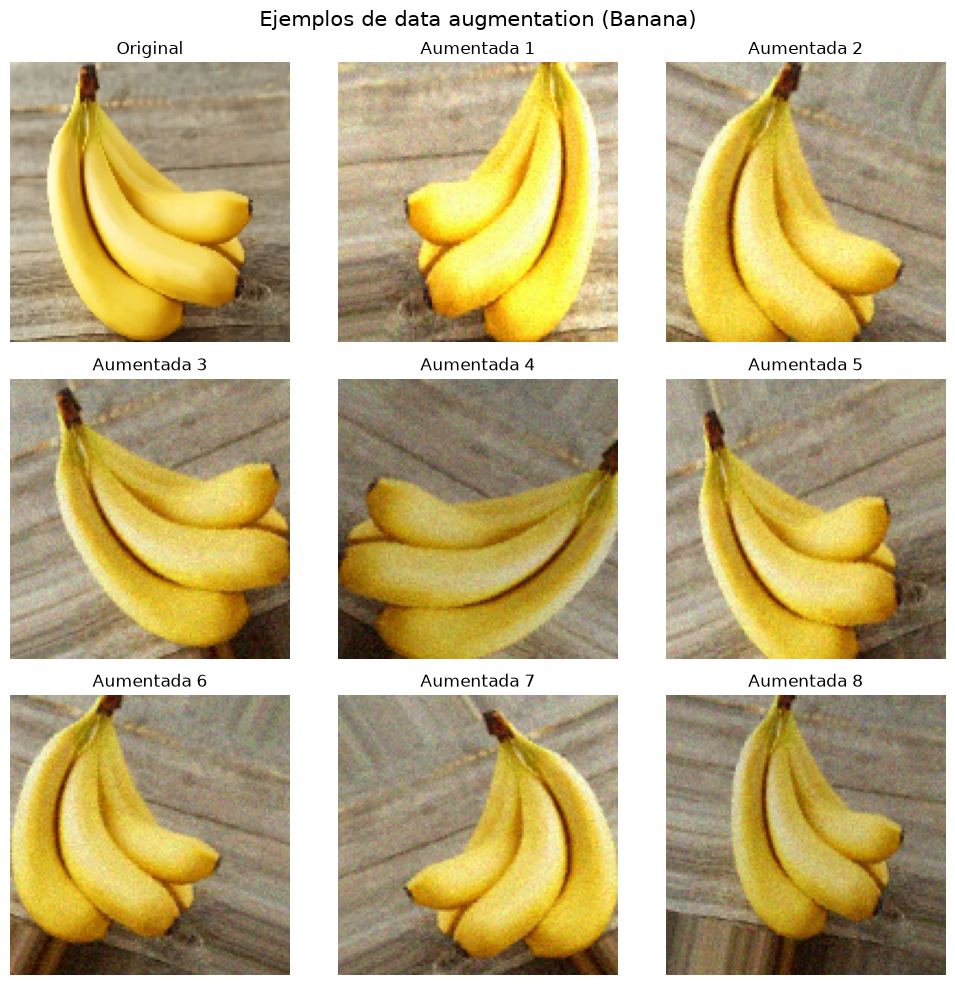

In [54]:
from tensorflow.keras.utils import load_img, img_to_array

# Tomar una imagen de entrenamiento y generar 8 versiones aumentadas
clase_ejemplo = 'Banana'
ruta_clase = os.path.join(RUTA_SPLIT, 'train', clase_ejemplo)
archivo = sorted(os.listdir(ruta_clase))[0]

img = load_img(os.path.join(ruta_clase, archivo), target_size=TAMANO_IMG)
x = np.expand_dims(img_to_array(img), axis=0)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

axes[0].imshow(img)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

aumentadas = generador_train.flow(x, batch_size=1, seed=SEMILLA)
for i in range(1, 9):
    lote = next(aumentadas)
    axes[i].imshow(lote[0])
    axes[i].set_title(f'Aumentada {i}', fontsize=12)
    axes[i].axis('off')

plt.suptitle(f'Ejemplos de data augmentation ({clase_ejemplo})', fontsize=15)
plt.tight_layout()
plt.savefig('outputs/data_augmentation.png', dpi=100)
plt.show()

In [55]:
imagenes, etiquetas = next(train_data)

print("Forma del lote de imágenes:", imagenes.shape)
print("Forma del lote de etiquetas:", etiquetas.shape)
print(f"Valor mínimo de los píxeles: {imagenes.min():.3f}")
print(f"Valor máximo de los píxeles: {imagenes.max():.3f}")
print("\nEjemplo de etiqueta (one-hot):", etiquetas[0])

Forma del lote de imágenes: (32, 128, 128, 3)
Forma del lote de etiquetas: (32, 6)
Valor mínimo de los píxeles: 0.000
Valor máximo de los píxeles: 1.000

Ejemplo de etiqueta (one-hot): [0. 1. 0. 0. 0. 0.]


### Resultados

`flow_from_directory` encontró 2,579 imágenes de entrenamiento, 551 de validación y 558 de prueba, distribuidas en las 6 clases. Keras asigna el índice de cada clase en orden alfabético según el nombre de la carpeta: Apple (0), Banana (1), Carrot (2), Cucumber (3), Orange (4) y Potato (5).

Cada lote contiene 32 imágenes de 128×128 píxeles con 3 canales de color, y los valores de los píxeles quedaron en el rango de 0 a 1. Las etiquetas están en formato one-hot: un vector de 6 posiciones con un 1 en la posición de la clase correspondiente, que es el formato que requiere la función de pérdida `categorical_crossentropy`.

El conjunto de entrenamiento se mezcla en cada época (`shuffle=True`) para que la red no aprenda el orden de las imágenes. En validación y prueba no se mezcla (`shuffle=False`), para que el orden de las predicciones coincida con el de las etiquetas reales al calcular la matriz de confusión.

## 2.4 Diseño y entrenamiento de las redes neuronales convolucionales

Se diseñaron tres arquitecturas de CNN. Cada una se construyó a partir de una idea distinta, variando el número de capas convolucionales, el tamaño de los filtros, el tipo de pooling, la forma de conectar la parte convolucional con la parte densa y las técnicas de regularización.

**Elementos comunes a las tres arquitecturas**

- Función de activación ReLU en las capas ocultas. Es la función más utilizada en CNN porque es simple de calcular y evita el problema del desvanecimiento del gradiente que tienen funciones como la sigmoide.
- Capa de salida con 6 neuronas (una por clase) y activación softmax, que convierte las salidas en probabilidades que suman 1.
- Función de pérdida `categorical_crossentropy`, que corresponde a un problema de clasificación multiclase con etiquetas one-hot.
- Padding `same` en las convoluciones, para que la convolución no reduzca el tamaño de la imagen y la reducción dependa solo de las capas de pooling.

**Parámetros de entrenamiento**

Los parámetros de entrenamiento se mantuvieron iguales en los tres modelos, para que las diferencias en los resultados se deban únicamente a la arquitectura:

| Parámetro | Valor | Justificación |
|---|---|---|
| Optimizador | Adam | Ajusta la tasa de aprendizaje de cada parámetro de forma automática, y suele converger más rápido que el descenso de gradiente estocástico sin ajustes adicionales |
| Tasa de aprendizaje inicial | 0.001 | Valor por defecto de Adam |
| Épocas máximas | 30 | Límite superior. El entrenamiento se detiene antes si el modelo deja de mejorar |
| Early stopping | paciencia de 6 épocas sobre `val_loss` | Detiene el entrenamiento si la pérdida de validación no mejora en 6 épocas y restaura los pesos de la mejor época, para evitar el sobreajuste |
| Reducción de la tasa de aprendizaje | factor 0.5, paciencia de 3 épocas | Si la pérdida de validación se estanca, la tasa de aprendizaje se reduce a la mitad para permitir ajustes más finos |
| Tamaño del lote | 32 imágenes | Definido en los generadores |

Antes de entrenar cada modelo se fijó la misma semilla aleatoria, para que los tres partan de condiciones comparables.

In [56]:
import time
from tensorflow.keras import layers, models, optimizers, callbacks

FORMA_ENTRADA = TAMANO_IMG + (3,)   # (128, 128, 3)
EPOCAS_MAX = 30

historiales = {}
tiempos = {}
modelos = {}

def entrenar_modelo(modelo, nombre):
    """Compila y entrena el modelo con los mismos parámetros para todos.
    Guarda el historial, el tiempo de entrenamiento y el modelo."""
    modelo.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    lista_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-5, verbose=1),
    ]

    inicio = time.time()
    historial = modelo.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCAS_MAX,
        callbacks=lista_callbacks,
        verbose=1
    )
    duracion = time.time() - inicio

    historiales[nombre] = historial.history
    tiempos[nombre] = duracion
    modelos[nombre] = modelo
    modelo.save(f'outputs/{nombre}.keras')

    print(f"\nTiempo de entrenamiento: {duracion/60:.1f} minutos")
    print(f"Épocas ejecutadas: {len(historial.history['loss'])}")
    return historial

### Modelo 1: CNN base

Es la arquitectura más simple, y se utilizó como punto de referencia para comparar las otras dos.

- 2 capas convolucionales con filtros de 3×3 (32 y 64 filtros), cada una seguida de MaxPooling de 2×2. El MaxPooling conserva el valor más alto de cada región, es decir, la característica más marcada que detectó el filtro.
- Una capa Flatten, que convierte el resultado de las convoluciones (32×32×64) en un vector de 65,536 valores.
- Una capa densa de 64 neuronas.
- Sin técnicas de regularización.

Como la imagen solo se reduce dos veces (de 128 a 32 píxeles por lado), el vector que sale del Flatten es muy grande. Por eso la capa densa concentra casi todos los parámetros del modelo (4.19 de los 4.21 millones).

In [57]:
def crear_modelo_1():
    return models.Sequential([
        layers.Input(shape=FORMA_ENTRADA),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(NUM_CLASES, activation='softmax'),
    ], name='modelo_1_base')

tf.keras.utils.set_random_seed(SEMILLA)
modelo_1 = crear_modelo_1()
modelo_1.summary()

Model: "modelo_1_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,150 (16.08 MB)

 Trainable params: 4,214,150 (16.08 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
historial_1 = entrenar_modelo(modelo_1, 'modelo_1_base')

Epoch 1/30
15/81 ━━━━━━━━━━━━━━━━━━━━ 19s 296ms/step - accuracy: 0.3229 - loss: 1.7063

c:\Users\luisi\Documents\Maestria BI\Analisis de datos\Text Mining & Image Recognition\Proyecto\.venv\Lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 28s 332ms/step - accuracy: 0.5789 - loss: 1.1296 - val_accuracy: 0.6788 - val_loss: 0.9242 - learning_rate: 0.0010
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.7949 - loss: 0.6077 - val_accuracy: 0.8929 - val_loss: 0.3936 - learning_rate: 0.0010
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - accuracy: 0.8554 - loss: 0.4406 - val_accuracy: 0.8911 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 188ms/step - accuracy: 0.8887 - loss: 0.3466 - val_accuracy: 0.8929 - val_loss: 0.3361 - learning_rate: 0.0010
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.8938 - loss: 0.3302 - val_accuracy: 0.9274 - val_loss: 0.2652 - learning_rate: 0.0010
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.8996 - loss: 0.2929 - val_accuracy: 0.9183 - val_loss: 0.2547 - learning_rate: 0.0010
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 379ms/step - accuracy: 0.9162 - loss: 0.2611 - val_

### Modelo 2: filtros grandes y AveragePooling

Esta arquitectura se diseñó para evaluar el efecto de usar filtros más grandes y un tipo de pooling distinto.

- 3 capas convolucionales con filtros de 5×5 (32, 64 y 128 filtros). Un filtro de 5×5 analiza un área de 25 píxeles en lugar de 9, por lo que desde las primeras capas puede detectar patrones más amplios, como curvas o bordes largos.
- AveragePooling de 2×2 después de cada convolución. A diferencia del MaxPooling, calcula el promedio de cada región, lo que suaviza la información en lugar de conservar solo el valor más alto.
- Una capa Flatten (16×16×128 = 32,768 valores) y una capa densa de 128 neuronas.
- Dropout de 0.4 antes de la capa de salida: durante el entrenamiento, el 40% de las neuronas de la capa densa se desactivan al azar en cada paso. Esto obliga a la red a no depender de neuronas específicas y reduce el sobreajuste.

El modelo tiene alrededor de 4.45 millones de parámetros. Igual que en el Modelo 1, la mayoría está en la capa densa.

In [59]:
def crear_modelo_2():
    return models.Sequential([
        layers.Input(shape=FORMA_ENTRADA),

        layers.Conv2D(32, (5, 5), activation='relu', padding='same'),
        layers.AveragePooling2D((2, 2)),

        layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
        layers.AveragePooling2D((2, 2)),

        layers.Conv2D(128, (5, 5), activation='relu', padding='same'),
        layers.AveragePooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASES, activation='softmax'),
    ], name='modelo_2_filtros_grandes')

tf.keras.utils.set_random_seed(SEMILLA)
modelo_2 = crear_modelo_2()
modelo_2.summary()

Model: "modelo_2_filtros_grandes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 64, 64, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 32, 32, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 16, 16, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,453,830 (16.99 MB)

 Trainable params: 4,453,830 (16.99 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
historial_2 = entrenar_modelo(modelo_2, 'modelo_2_filtros_grandes')

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 227ms/step - accuracy: 0.3339 - loss: 1.6136 - val_accuracy: 0.5227 - val_loss: 1.3059 - learning_rate: 0.0010
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.5684 - loss: 1.1175 - val_accuracy: 0.6915 - val_loss: 0.8134 - learning_rate: 0.0010
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 221ms/step - accuracy: 0.6851 - loss: 0.8711 - val_accuracy: 0.7550 - val_loss: 0.6700 - learning_rate: 0.0010
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 222ms/step - accuracy: 0.7301 - loss: 0.7786 - val_accuracy: 0.7641 - val_loss: 0.7447 - learning_rate: 0.0010
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.7569 - loss: 0.7137 - val_accuracy: 0.8621 - val_loss: 0.4650 - learning_rate: 0.0010
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 221ms/step - accuracy: 0.7902 - loss: 0.6427 - val_accuracy: 0.8294 - val_loss: 0.5184 - learning_rate: 0.0010
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.8302 - loss: 0.

### Modelo 3: CNN profunda con BatchNormalization y GlobalAveragePooling

Esta arquitectura se diseñó para evaluar si una red más profunda, pero con menos parámetros, obtiene mejores resultados.

- 4 bloques convolucionales con filtros de 3×3 (32, 64, 128 y 256 filtros). Cada bloque tiene una convolución, BatchNormalization y MaxPooling de 2×2. Al tener más capas, la red puede aprender características en varios niveles: las primeras capas detectan bordes y colores, y las últimas combinan esos patrones en formas más complejas.
- BatchNormalization después de cada convolución. Normaliza las salidas de la capa en cada lote, lo que estabiliza y acelera el entrenamiento.
- GlobalAveragePooling en lugar de Flatten. Calcula el promedio de cada uno de los 256 mapas de características, así que el resultado es un vector de solo 256 valores (en lugar de decenas de miles). Esto reduce drásticamente el número de parámetros de la capa densa.
- Dropout de 0.5 y una capa densa de 128 neuronas.

El modelo tiene alrededor de 424 mil parámetros, aproximadamente 10 veces menos que los otros dos modelos, aunque tiene más capas convolucionales.


In [61]:
def crear_modelo_3():
    return models.Sequential([
        layers.Input(shape=FORMA_ENTRADA),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASES, activation='softmax'),
    ], name='modelo_3_profundo')

tf.keras.utils.set_random_seed(SEMILLA)
modelo_3 = crear_modelo_3()
modelo_3.summary()

Model: "modelo_3_profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [62]:
historial_3 = entrenar_modelo(modelo_3, 'modelo_3_profundo')

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 257ms/step - accuracy: 0.6778 - loss: 0.9137 - val_accuracy: 0.1688 - val_loss: 2.7999 - learning_rate: 0.0010
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.8259 - loss: 0.5157 - val_accuracy: 0.1652 - val_loss: 2.9875 - learning_rate: 0.0010
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.8596 - loss: 0.4238 - val_accuracy: 0.2105 - val_loss: 2.6922 - learning_rate: 0.0010
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.8829 - loss: 0.3414 - val_accuracy: 0.3358 - val_loss: 2.4435 - learning_rate: 0.0010
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.9019 - loss: 0.2867 - val_accuracy: 0.4664 - val_loss: 1.8473 - learning_rate: 0.0010
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.9062 - loss: 0.2888 - val_accuracy: 0.7350 - val_loss: 0.7839 - learning_rate: 0.0010
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.9066 - loss: 0.

## 2.5 Comparación de las arquitecturas

La selección del mejor modelo se hizo con el conjunto de validación, utilizando los pesos de la mejor época de cada modelo (la época con menor pérdida de validación, restaurada por el early stopping). Se comparó la accuracy y la pérdida de validación, y la diferencia entre la accuracy de entrenamiento y la de validación como indicador de sobreajuste.

El conjunto de prueba se utilizó después de la selección, para medir el desempeño final con imágenes que no intervinieron en ninguna decisión del entrenamiento ni de la selección.

Además, para evaluar la robustez que pide el enunciado, los tres modelos se evaluaron sobre una versión modificada del conjunto de prueba, a la que se le aplicaron rotaciones, cambios de escala y cambios de iluminación.

In [64]:
%pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.


In [65]:
filas = []
for nombre, h in historiales.items():
    mejor = int(np.argmin(h['val_loss']))   # índice de la mejor época
    filas.append({
        'Modelo': nombre,
        'Parámetros': modelos[nombre].count_params(),
        'Épocas ejecutadas': len(h['loss']),
        'Mejor época': mejor + 1,
        'Accuracy entrenamiento': h['accuracy'][mejor],
        'Accuracy validación': h['val_accuracy'][mejor],
        'Pérdida validación': h['val_loss'][mejor],
        'Diferencia (train - val)': h['accuracy'][mejor] - h['val_accuracy'][mejor],
        'Tiempo (min)': tiempos[nombre] / 60,
    })

comparacion = pd.DataFrame(filas).set_index('Modelo')
comparacion.style.format({
    'Parámetros': '{:,}',
    'Accuracy entrenamiento': '{:.2%}',
    'Accuracy validación': '{:.2%}',
    'Pérdida validación': '{:.4f}',
    'Diferencia (train - val)': '{:.2%}',
    'Tiempo (min)': '{:.1f}',
})

,Parámetros,Épocas ejecutadas,Mejor época,Accuracy entrenamiento,Accuracy validación,Pérdida validación,Diferencia (train - val),Tiempo (min)
Modelo,,,,,,,,
modelo_1_base,"4,214,150",27,21,97.60%,96.91%,0.1577,0.68%,18.6
modelo_2_filtros_grandes,"4,453,830",30,29,96.90%,97.46%,0.1384,-0.56%,9.0
modelo_3_profundo,"424,006",30,26,98.06%,97.46%,0.0893,0.60%,10.2


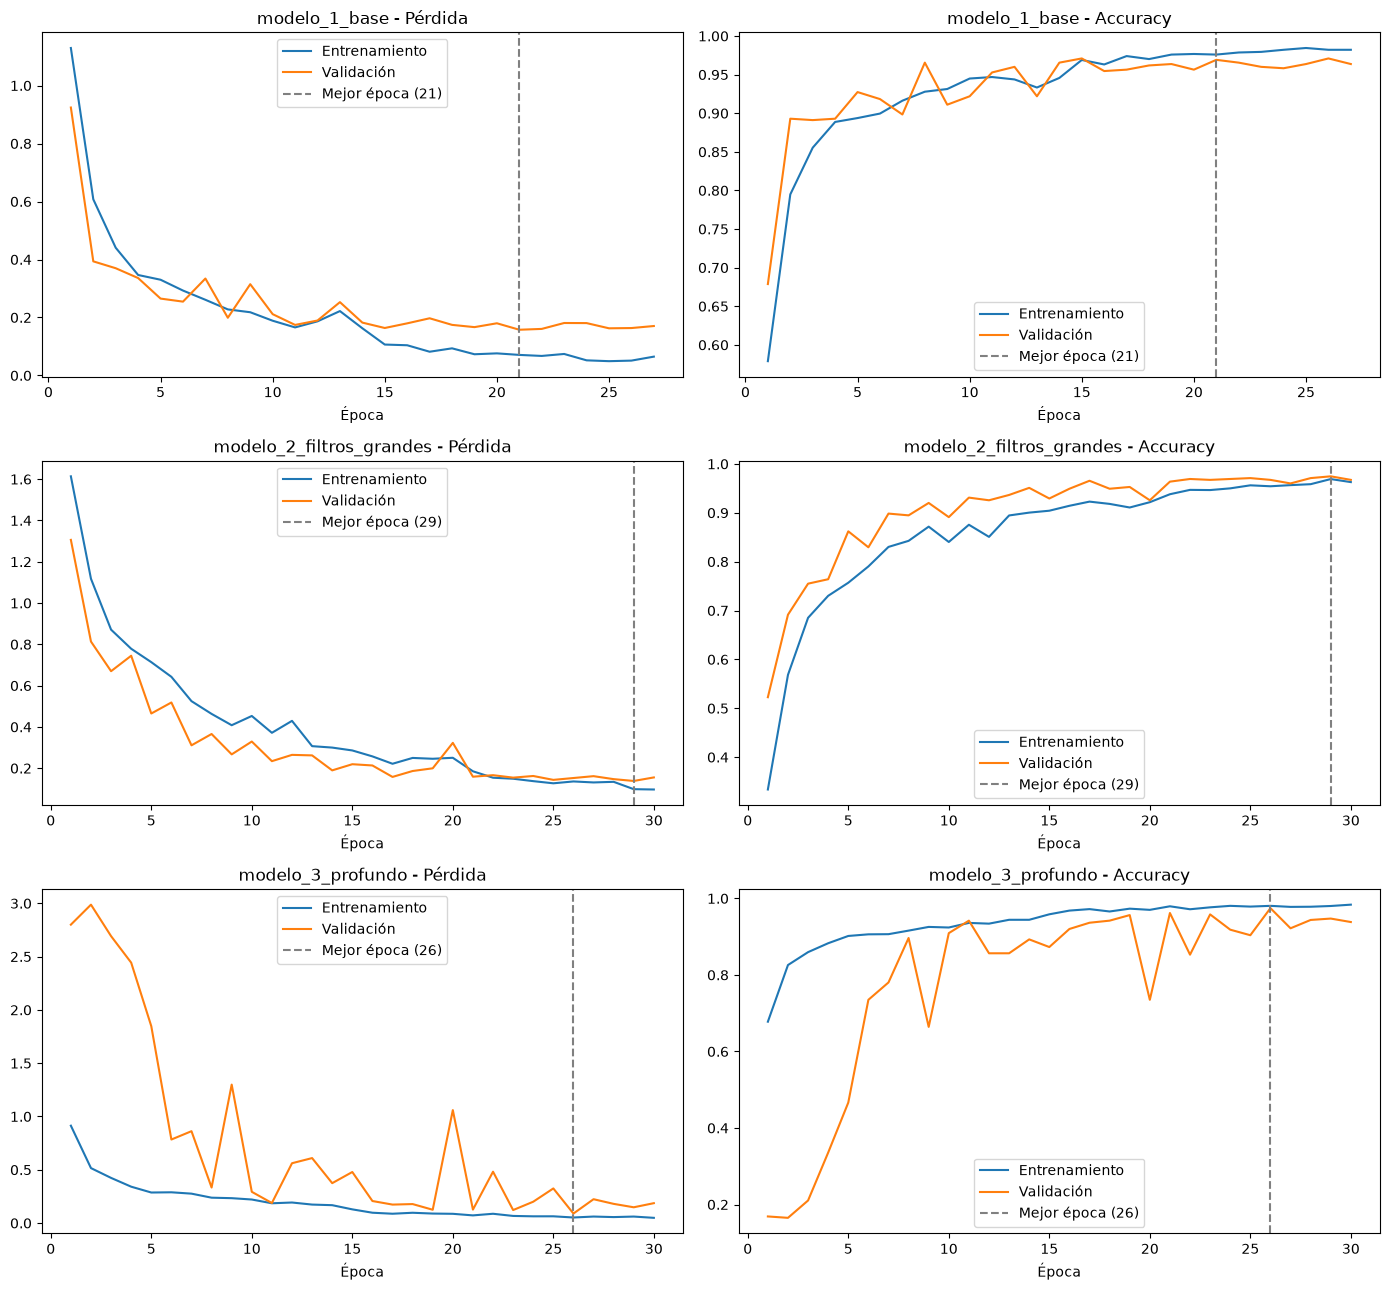

In [66]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for fila, (nombre, h) in enumerate(historiales.items()):
    epocas = range(1, len(h['loss']) + 1)
    mejor = int(np.argmin(h['val_loss'])) + 1

    # Pérdida
    axes[fila, 0].plot(epocas, h['loss'], label='Entrenamiento')
    axes[fila, 0].plot(epocas, h['val_loss'], label='Validación')
    axes[fila, 0].axvline(mejor, color='gray', linestyle='--', label=f'Mejor época ({mejor})')
    axes[fila, 0].set_title(f'{nombre} - Pérdida')
    axes[fila, 0].set_xlabel('Época')
    axes[fila, 0].legend()

    # Accuracy
    axes[fila, 1].plot(epocas, h['accuracy'], label='Entrenamiento')
    axes[fila, 1].plot(epocas, h['val_accuracy'], label='Validación')
    axes[fila, 1].axvline(mejor, color='gray', linestyle='--', label=f'Mejor época ({mejor})')
    axes[fila, 1].set_title(f'{nombre} - Accuracy')
    axes[fila, 1].set_xlabel('Época')
    axes[fila, 1].legend()

plt.tight_layout()
plt.savefig('outputs/curvas_entrenamiento.png', dpi=100)
plt.show()

In [67]:
evaluacion = []
for nombre, modelo in modelos.items():
    val_loss, val_acc = modelo.evaluate(val_data, verbose=0)
    test_loss, test_acc = modelo.evaluate(test_data, verbose=0)
    evaluacion.append({
        'Modelo': nombre,
        'Accuracy validación': val_acc,
        'Accuracy prueba': test_acc,
        'Pérdida prueba': test_loss,
    })

evaluacion = pd.DataFrame(evaluacion).set_index('Modelo')
evaluacion.style.format({'Accuracy validación': '{:.2%}',
                         'Accuracy prueba': '{:.2%}',
                         'Pérdida prueba': '{:.4f}'})

,Accuracy validación,Accuracy prueba,Pérdida prueba
Modelo,,,
modelo_1_base,96.91%,97.85%,0.0843
modelo_2_filtros_grandes,97.46%,98.57%,0.0729
modelo_3_profundo,97.46%,98.57%,0.0509


In [69]:
# Generador con transformaciones para evaluar robustez
# (rotación, escala e iluminación; sin ruido ni desplazamiento)
generador_robustez = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

SEMILLAS_ROBUSTEZ = [42, 7, 123]

def accuracy_modificada(modelo, conjunto):
    """Accuracy promedio del modelo sobre el conjunto con transformaciones,
    repitiendo la evaluación con varias semillas."""
    resultados = []
    for semilla in SEMILLAS_ROBUSTEZ:
        datos = generador_robustez.flow_from_directory(
            os.path.join(RUTA_SPLIT, conjunto),
            target_size=TAMANO_IMG, color_mode='rgb', batch_size=BATCH_SIZE,
            class_mode='categorical', shuffle=False, seed=semilla
        )
        _, acc = modelo.evaluate(datos, verbose=0)
        resultados.append(acc)
    return np.mean(resultados), np.std(resultados)

robustez = []
for nombre, modelo in modelos.items():
    val_mod, val_std = accuracy_modificada(modelo, 'val')
    test_mod, test_std = accuracy_modificada(modelo, 'test')
    robustez.append({
        'Modelo': nombre,
        'Val original': evaluacion.loc[nombre, 'Accuracy validación'],
        'Val modificada': val_mod,
        'Val mod. (desv.)': val_std,
        'Test original': evaluacion.loc[nombre, 'Accuracy prueba'],
        'Test modificado': test_mod,
        'Test mod. (desv.)': test_std,
    })

robustez = pd.DataFrame(robustez).set_index('Modelo')
robustez.style.format('{:.2%}')

Found 551 images belonging to 6 classes.


Found 551 images belonging to 6 classes.
Found 551 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Found 551 images belonging to 6 classes.
Found 551 images belonging to 6 classes.
Found 551 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Found 551 images belonging to 6 classes.
Found 551 images belonging to 6 classes.
Found 551 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Found 558 images belonging to 6 classes.
Found 558 images belonging to 6 classes.


,Val original,Val modificada,Val mod. (desv.),Test original,Test modificado,Test mod. (desv.)
Modelo,,,,,,
modelo_1_base,96.91%,94.86%,0.67%,97.85%,97.07%,0.08%
modelo_2_filtros_grandes,97.46%,96.49%,0.17%,98.57%,97.97%,0.34%
modelo_3_profundo,97.46%,92.26%,0.17%,98.57%,95.28%,0.61%


### Resultados de la comparación

| Modelo | Parámetros | Mejor época | Accuracy validación | Pérdida validación | Accuracy prueba | Tiempo |
|---|---|---|---|---|---|---|
| 1 - Base | 4,214,150 | 21 de 27 | 96.91% | 0.1577 | 97.85% | 18.6 min |
| 2 - Filtros grandes | 4,453,830 | 29 de 30 | 97.46% | 0.1384 | 98.57% | 9.0 min |
| 3 - Profundo | 424,006 | 26 de 30 | 97.46% | 0.0893 | 98.57% | 10.2 min |

Los tres modelos superaron el 96% de accuracy en validación. Los modelos 2 y 3 obtuvieron exactamente la misma accuracy tanto en validación (537 de 551 imágenes) como en prueba (550 de 558), mientras que el Modelo 3 obtuvo la menor pérdida en ambos conjuntos.

En las curvas de entrenamiento se observaron comportamientos distintos en cada modelo:

- Modelo 1: a partir de la época 15, la pérdida de validación se mantuvo entre 0.16 y 0.18, mientras que la de entrenamiento siguió bajando hasta cerca de 0.05. Esta separación indica el inicio del sobreajuste, y el early stopping detuvo el entrenamiento en la época 27.
- Modelo 2: la accuracy de validación fue mayor que la de entrenamiento en casi todas las épocas. Esto se debe a que el dropout y el data augmentation solo se aplican durante el entrenamiento, por lo que las métricas de entrenamiento se calculan sobre imágenes modificadas y con neuronas desactivadas. La mejor época fue la 29 de 30, y el early stopping no llegó a activarse, por lo que no se puede descartar que el modelo hubiera mejorado con más épocas.
- Modelo 3: en las primeras 5 épocas, la accuracy de validación estuvo entre 17% y 47%, mientras que la de entrenamiento ya estaba entre 68% y 90%. Un 17% equivale a elegir una clase al azar entre 6. La curva de validación presentó picos de pérdida en las épocas 9, 20 y 22, y se estabilizó en las últimas épocas. Este comportamiento es conocido en redes con BatchNormalization: durante el entrenamiento, la capa normaliza con las estadísticas de cada lote, pero en validación usa promedios acumulados que en las primeras épocas todavía no representan bien los datos.

El Modelo 1 fue el que más tardó en entrenar (18.6 minutos, 512 ms por paso), a pesar de tener menos capas que los otros dos.

### Criterio de selección

El enunciado pide que el modelo sea robusto ante variaciones de tamaño, rotación e iluminación, por lo que la selección no se basó únicamente en la accuracy sobre imágenes sin modificar. Para evaluar la robustez, cada modelo se evaluó también sobre el conjunto de validación con transformaciones aleatorias de rotación (±30°), escala (±20%) e iluminación (±30%). La evaluación se repitió con 3 semillas distintas y se promedió el resultado, para reducir el efecto del azar en las transformaciones.

El criterio de selección, definido antes de obtener estos resultados, fue el siguiente: se seleccionó el modelo con mayor promedio entre la accuracy de validación original y la accuracy de validación modificada. En caso de empate, se eligió el de menor pérdida de validación.

El conjunto de prueba (original y modificado) se utilizó solo para reportar el desempeño final, no para seleccionar el modelo.

In [70]:
seleccion = robustez[['Val original', 'Val modificada']].copy()
seleccion['Promedio'] = seleccion.mean(axis=1)
seleccion['Pérdida validación'] = comparacion['Pérdida validación']

seleccion = seleccion.sort_values(['Promedio', 'Pérdida validación'],
                                  ascending=[False, True])
nombre_mejor = seleccion.index[0]

display(seleccion.style.format({'Val original': '{:.2%}', 'Val modificada': '{:.2%}',
                                'Promedio': '{:.2%}', 'Pérdida validación': '{:.4f}'}))
print(f"\nModelo seleccionado: {nombre_mejor}")

,Val original,Val modificada,Promedio,Pérdida validación
Modelo,,,,
modelo_2_filtros_grandes,97.46%,96.49%,96.98%,0.1384
modelo_1_base,96.91%,94.86%,95.89%,0.1577
modelo_3_profundo,97.46%,92.26%,94.86%,0.0893



Modelo seleccionado: modelo_2_filtros_grandes


### Resultados de la prueba de robustez

| Modelo | Val original | Val modificada | Caída en validación | Test original | Test modificado | Caída en prueba |
|---|---|---|---|---|---|---|
| 1 - Base | 96.91% | 94.86% | 2.05 puntos | 97.85% | 97.07% | 0.78 puntos |
| 2 - Filtros grandes | 97.46% | 96.49% | 0.97 puntos | 98.57% | 97.97% | 0.60 puntos |
| 3 - Profundo | 97.46% | 92.26% | 5.20 puntos | 98.57% | 95.28% | 3.29 puntos |

Al aplicar rotaciones, cambios de escala y cambios de iluminación, los tres modelos redujeron su accuracy, pero en distinta medida. El Modelo 2 obtuvo la mayor accuracy sobre las imágenes modificadas tanto en validación como en prueba, y fue el que menos cayó en ambos conjuntos. El Modelo 3, que había obtenido la menor pérdida de validación sobre imágenes sin modificar, fue el que más cayó: 5.20 puntos en validación y 3.29 en prueba.

La desviación estándar entre las 3 repeticiones fue de 0.67% o menos en todos los casos. Esto indica que las diferencias entre modelos no se deben al azar de las transformaciones: por ejemplo, en validación modificada la diferencia entre el Modelo 2 y el Modelo 3 fue de 4.23 puntos.

Con el criterio de selección definido (promedio entre la accuracy de validación original y la modificada), el modelo seleccionado fue el **Modelo 2 (filtros grandes y AveragePooling)**, con un promedio de 96.98%, seguido del Modelo 1 (95.89%) y el Modelo 3 (94.86%).

En el conjunto de prueba, el Modelo 2 obtuvo una accuracy de 98.57% sobre las imágenes originales y de 97.97% sobre las imágenes modificadas.

Reporte de clasificación - modelo_2_filtros_grandes (conjunto de prueba)

              precision    recall  f1-score   support

       Apple     0.9688    1.0000    0.9841        93
      Banana     0.9691    0.9895    0.9792        95
      Carrot     1.0000    0.9892    0.9946        93
    Cucumber     1.0000    0.9891    0.9945        92
      Orange     0.9785    0.9891    0.9838        92
      Potato     1.0000    0.9570    0.9780        93

    accuracy                         0.9857       558
   macro avg     0.9861    0.9857    0.9857       558
weighted avg     0.9860    0.9857    0.9857       558



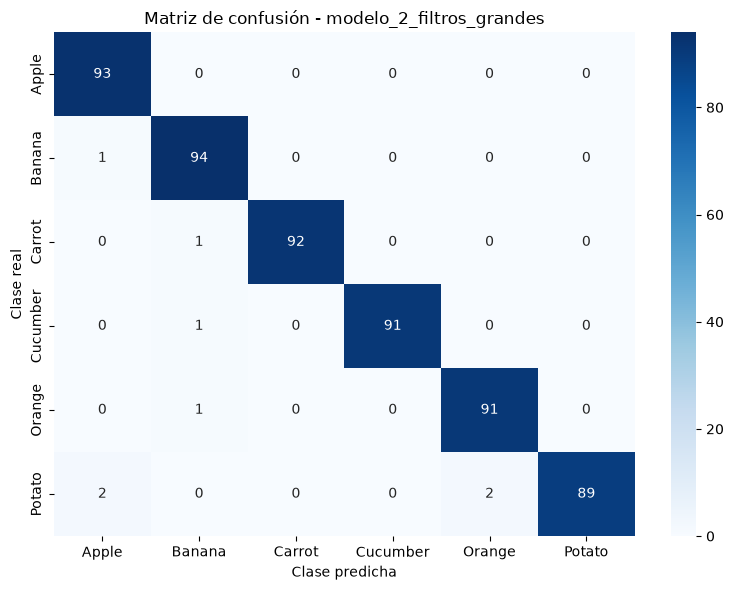

In [71]:
from sklearn.metrics import confusion_matrix, classification_report

modelo_final = modelos[nombre_mejor]

# Predicciones sobre el conjunto de prueba original
test_data.reset()
probabilidades = modelo_final.predict(test_data, verbose=0)
y_pred = probabilidades.argmax(axis=1)
y_true = test_data.classes

print(f"Reporte de clasificación - {nombre_mejor} (conjunto de prueba)\n")
print(classification_report(y_true, y_pred, target_names=NOMBRES_CLASES, digits=4))

matriz = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=NOMBRES_CLASES, yticklabels=NOMBRES_CLASES)
plt.title(f'Matriz de confusión - {nombre_mejor}')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.tight_layout()
plt.savefig('outputs/matriz_confusion.png', dpi=150)
plt.show()

Imágenes mal clasificadas: 8 de 558


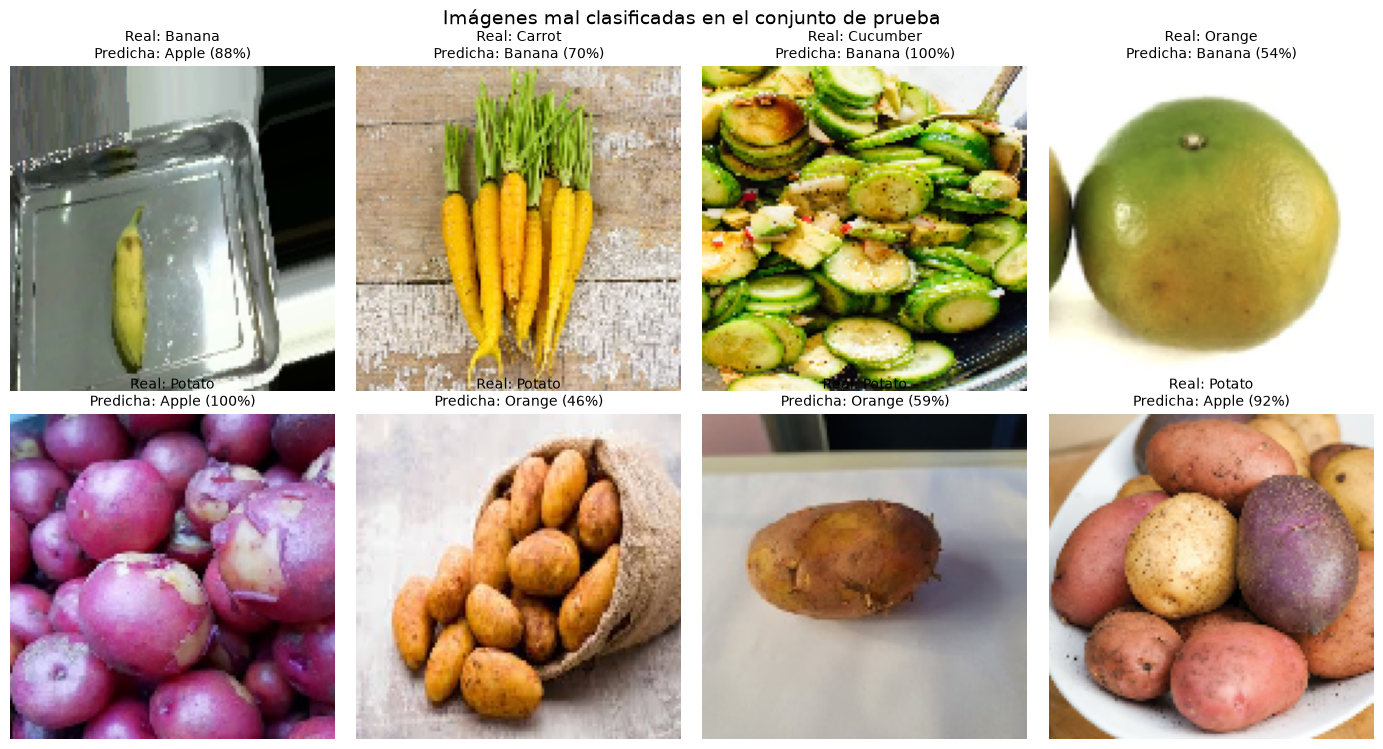

In [72]:
errores = np.where(y_pred != y_true)[0]
print(f"Imágenes mal clasificadas: {len(errores)} de {len(y_true)}")

if len(errores) > 0:
    columnas = 4
    filas = int(np.ceil(len(errores) / columnas))
    fig, axes = plt.subplots(filas, columnas, figsize=(14, 3.8 * filas))
    axes = np.array(axes).reshape(-1)

    for ax, i in zip(axes, errores):
        img = load_img(test_data.filepaths[i], target_size=TAMANO_IMG)
        ax.imshow(img)
        ax.set_title(f"Real: {NOMBRES_CLASES[y_true[i]]}\n"
                     f"Predicha: {NOMBRES_CLASES[y_pred[i]]} ({probabilidades[i].max():.0%})",
                     fontsize=10)
        ax.axis('off')

    for ax in axes[len(errores):]:
        ax.axis('off')

    plt.suptitle('Imágenes mal clasificadas en el conjunto de prueba', fontsize=14)
    plt.tight_layout()
    plt.savefig('outputs/errores_clasificacion.png', dpi=100)
    plt.show()

## 2.6 ¿Por qué se cree que la CNN seleccionada funciona mejor que las otras?

**Lo que se midió**

Sobre imágenes sin modificar, los modelos 2 y 3 obtuvieron la misma accuracy en validación y en prueba, y el Modelo 1 quedó ligeramente por debajo. La diferencia principal apareció al evaluar la robustez: el Modelo 2 mantuvo su desempeño al aplicar rotaciones, cambios de escala y cambios de iluminación (una caída de 0.97 puntos en validación), mientras que el Modelo 3 perdió 5.20 puntos. Como el enunciado pide un modelo robusto ante estas variaciones, el Modelo 2 es el que mejor cumple el objetivo del problema.

En las curvas de entrenamiento, el Modelo 2 fue el único en el que la accuracy de validación se mantuvo por encima de la de entrenamiento durante casi todo el entrenamiento, sin señales de sobreajuste. El Modelo 1 mostró una separación creciente entre la pérdida de entrenamiento y la de validación, y el Modelo 3 tuvo una curva de validación inestable.

**Por qué se cree que el Modelo 2 es más robusto**

Se identificaron tres características de su arquitectura que podrían explicar este resultado:

1. Filtros de 5×5: cada filtro analiza un área más amplia de la imagen que uno de 3×3, por lo que desde las primeras capas la red puede aprender patrones de forma general (el contorno alargado de una banana o de un pepino, la forma redonda de una naranja). La forma general de un objeto cambia poco al rotarlo o al variar la iluminación, a diferencia de los detalles pequeños de textura.
2. AveragePooling: al promediar cada región en lugar de conservar solo el valor máximo, el resultado depende menos de píxeles individuales. Un cambio de iluminación o una rotación altera los valores de píxeles puntuales, y el promedio amortigua ese efecto.
3. Dropout de 0.4: obliga a la red a no depender de neuronas específicas, lo que favorece que aprenda características más generales.

En el caso del Modelo 3, se cree que su menor robustez está relacionada con el BatchNormalization. Durante la evaluación, estas capas normalizan con promedios calculados sobre las imágenes de entrenamiento. Cuando se evalúan imágenes con otra iluminación, los valores de entrada cambian y esa normalización fija podría dejar de ser adecuada. Esto es consistente con la inestabilidad que mostró su curva de validación durante el entrenamiento.

**Limitación**

Cada arquitectura modificó varios elementos al mismo tiempo (número de capas, tamaño de filtro, tipo de pooling y regularización), por lo que este análisis no permite determinar cuál de ellos causó la diferencia en robustez. Las explicaciones anteriores son hipótesis basadas en cómo funciona cada componente. Para confirmarlas sería necesario entrenar variantes que cambien un solo elemento a la vez, por ejemplo, el Modelo 2 con MaxPooling en lugar de AveragePooling. Tampoco se puede descartar que el Modelo 2 hubiera mejorado con más épocas, ya que su mejor época fue la 29 de 30.

### Análisis de errores

En el conjunto de prueba, el modelo seleccionado obtuvo una accuracy de 98.57%, con 8 imágenes mal clasificadas de 558.

| Clase | Precision | Recall | F1-score | Imágenes |
|---|---|---|---|---|
| Apple | 96.88% | 100.00% | 98.41% | 93 |
| Banana | 96.91% | 98.95% | 97.92% | 95 |
| Carrot | 100.00% | 98.92% | 99.46% | 93 |
| Cucumber | 100.00% | 98.91% | 99.45% | 92 |
| Orange | 97.85% | 98.91% | 98.38% | 92 |
| Potato | 100.00% | 95.70% | 97.80% | 93 |
| Promedio (macro) | 98.61% | 98.57% | 98.57% | 558 |

La clase con menor recall fue Potato (95.70%), con 4 de los 8 errores: 2 imágenes se clasificaron como Apple y 2 como Orange. Todas las imágenes que el modelo clasificó como Potato eran realmente papas (precision de 100%). Banana fue la clase predicha en 3 de los errores (una zanahoria, un pepino y una naranja).

Al revisar las imágenes mal clasificadas se observó que en todos los casos el producto tiene un color o una presentación distinta a la mayoría de imágenes de su clase:

- Las 2 papas clasificadas como manzana tienen cáscara roja o morada.
- Las 2 papas clasificadas como naranja son redondas y de color dorado.
- La zanahoria clasificada como banana es de color amarillo, no anaranjado.
- La naranja clasificada como banana tiene la cáscara verde.
- El pepino clasificado como banana aparece en rodajas dentro de una ensalada, no entero.
- La banana clasificada como manzana ocupa una parte pequeña de la imagen, dentro de una bandeja metálica.

En 4 de los errores el modelo asignó una probabilidad alta a la clase incorrecta (entre 88% y 100%), y en 3 la probabilidad fue baja (entre 46% y 59%), lo que indica que en esos casos el modelo no tenía una predicción clara.

Se cree que estos errores muestran que el color es una de las características en las que más se apoya el modelo: los productos con un color poco común para su clase se confundieron con la clase que normalmente tiene ese color. Esto es consistente con la decisión de trabajar con imágenes a color, pero también indica que el modelo podría mejorar con más imágenes de variedades menos comunes, como papas rojas o zanahorias amarillas.

## Conclusión del Problema 2

Se desarrolló un clasificador de imágenes para 6 clases (3 frutas y 3 verduras) basado en redes neuronales convolucionales. Las imágenes se trabajaron a color, se redimensionaron a 128×128 píxeles y se normalizaron entre 0 y 1. Durante el entrenamiento se aplicaron rotaciones, escalado, desplazamientos, flip horizontal, cambios de brillo y ruido gaussiano.

Se compararon tres arquitecturas. Sobre imágenes sin modificar, las tres superaron el 96% de accuracy en validación, y los modelos 2 y 3 empataron. La diferencia entre ellas apareció al evaluar la robustez con imágenes rotadas, escaladas y con otra iluminación: el Modelo 2 (filtros de 5×5, AveragePooling y Dropout) fue el que mejor mantuvo su desempeño, por lo que fue el seleccionado.

En el conjunto de prueba, el modelo seleccionado obtuvo una accuracy de 98.57% sobre las imágenes originales y de 97.97% sobre las imágenes modificadas. Los errores se concentraron en productos con colores o presentaciones poco comunes para su clase, principalmente papas de cáscara roja o dorada.

Un resultado relevante del análisis fue que el modelo con menor pérdida de validación (Modelo 3) resultó ser el menos robusto. Esto muestra que evaluar un modelo solo con imágenes similares a las de entrenamiento puede no reflejar su desempeño ante las variaciones que se esperan en la práctica.